# Data preparation - default KO data - feature based on operon list

## load pq files and check data format

In [1]:
import pandas as pd

file_path = "/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_gene_knockout_102trails_seed100_all.parquet"

df = pd.read_parquet(file_path)

print("=" * 80)
print("Shape:")
print(df.shape)

print("\n" + "=" * 80)
print("Columns:")
for col in df.columns:
    print(col)

print("\n" + "=" * 80)
print("Data types:")
print(df.dtypes)

print("\n" + "=" * 80)
print("First 5 rows:")
print(df.head())

Shape:
(63482, 6)

Columns:
project
variant
label
time
listeners__mass__instantaneous_growth_rate
listeners__mass__dry_mass

Data types:
project                                        object
variant                                         int64
label                                          object
time                                          float64
listeners__mass__instantaneous_growth_rate    float64
listeners__mass__dry_mass                     float64
dtype: object

First 5 rows:
                      project  variant     label  time  \
0  gene_knockout_3_round_test        0  baseline   0.0   
1  gene_knockout_3_round_test        0  baseline  20.0   
2  gene_knockout_3_round_test        0  baseline  40.0   
3  gene_knockout_3_round_test        0  baseline  60.0   
4  gene_knockout_3_round_test        0  baseline  80.0   

   listeners__mass__instantaneous_growth_rate  listeners__mass__dry_mass  
0                                    0.000000                 266.478760  
1          

In [2]:
print("\n" + "=" * 80)
print("First 10 rows:") #read interval needs to be changed
print(df.head(20))


First 10 rows:
                       project  variant     label   time  \
0   gene_knockout_3_round_test        0  baseline    0.0   
1   gene_knockout_3_round_test        0  baseline   20.0   
2   gene_knockout_3_round_test        0  baseline   40.0   
3   gene_knockout_3_round_test        0  baseline   60.0   
4   gene_knockout_3_round_test        0  baseline   80.0   
5   gene_knockout_3_round_test        0  baseline  100.0   
6   gene_knockout_3_round_test        0  baseline  120.0   
7   gene_knockout_3_round_test        0  baseline  140.0   
8   gene_knockout_3_round_test        0  baseline  160.0   
9   gene_knockout_3_round_test        0  baseline  180.0   
10  gene_knockout_3_round_test        0  baseline  200.0   
11  gene_knockout_3_round_test        0  baseline  220.0   
12  gene_knockout_3_round_test        0  baseline  240.0   
13  gene_knockout_3_round_test        0  baseline  260.0   
14  gene_knockout_3_round_test        0  baseline  280.0   
15  gene_knockout_3_roun

## Operon-level training data construction

### Double-check total unique TU ids

In [3]:
import pandas as pd

file_path = "/user/home/il22158/work/vEcoli/reading/imported/inferred_operons_from_TUs.csv"

df = pd.read_csv(file_path)

# count unique operon IDs (from conversion step)
unique_operon = df["operon_ids"].nunique()

print("Unique operon IDs:", unique_operon)

Unique operon IDs: 334


### Training data construction

In [4]:
import pandas as pd

# ----------------------------
# Paths
# ----------------------------
summary_file = "/user/home/il22158/work/vEcoli/surrogate/results/default_KO/gene_knockout_generation_summary.csv"
classification_file = "/user/home/il22158/work/vEcoli/surrogate/operon_classification.csv"
operon_map_file = "/user/home/il22158/work/vEcoli/reading/imported/inferred_operons_from_TUs.csv"

output_file = "/user/home/il22158/work/vEcoli/surrogate/results/default_KO/gene_knockout_generation_summary_operon_selective.csv"

# ----------------------------
# Load data
# ----------------------------
df = pd.read_csv(summary_file, engine="python")
class_df = pd.read_csv(classification_file)
operon_df = pd.read_csv(operon_map_file)

# ----------------------------
# TU -> operon mapping from the cited operon table
# ----------------------------
tu_to_operon = {}
for _, row in operon_df.iterrows():
    operon_id = pd.to_numeric(row["operon_ids"], errors="coerce")
    if pd.isna(operon_id):
        continue
    operon_id = int(operon_id)
    tu_ids = [tu.strip() for tu in str(row["tu_ids"]).split(";") if tu.strip()]
    for tu_id in tu_ids:
        tu_to_operon[tu_id] = operon_id

# ----------------------------
# Gene -> TU bridge, then TU -> operon
# ----------------------------
gene_to_tu = dict(zip(class_df["id"], class_df["tu_id"]))
if "symbol" in class_df.columns:
    gene_to_tu.update(dict(zip(class_df["symbol"], class_df["tu_id"])))

# ----------------------------
# Convert labels to numeric operon ids
# ----------------------------
def convert_to_operon(val):
    if pd.isna(val):
        return pd.NA

    val = str(val).strip()
    if not val or val == "baseline":
        return pd.NA

    direct_operon = tu_to_operon.get(val)
    if direct_operon is not None:
        return direct_operon

    tu_id = gene_to_tu.get(val)
    if tu_id is not None:
        return tu_to_operon.get(str(tu_id).strip(), pd.NA)

    return pd.NA

# ----------------------------
# Apply conversion
# ----------------------------
df["operon_id"] = df["gene_knockout"].apply(convert_to_operon).astype("Int64")

# ----------------------------
# Diagnostics
# ----------------------------
missing = df[df["operon_id"].isna()]["gene_knockout"].unique()

print("Unmapped values:", len(missing))
print(missing[:20])
print("Unique operons:", df["operon_id"].nunique(dropna=True))

# ----------------------------
# Save
# ----------------------------
df.to_csv(output_file, index=False)

print("Saved:", output_file)

Unmapped values: 1
['baseline']
Unique operons: 334
Saved: /user/home/il22158/work/vEcoli/surrogate/results/default_KO/gene_knockout_generation_summary_operon_selective.csv


In [5]:
"""Drop inaccurate columns (as they ignore TU-operon hierarchy): 
associated_gene_total_numbers, 
operon_has_additional_genes_not_in_rest_gene_to_test,
n_additional_genes_not_in_rest_gene_to_test	genes_not_in_rest_gene_to_test,	
in_rest_tu_ids_to_test,	
in_rest_genes_to_test,	
source_file.
"""
path = "/user/home/il22158/work/vEcoli/surrogate/results/default_KO/gene_knockout_generation_summary_operon_selective.csv"
with pd.option_context('display.max_columns', None):
    df = pd.read_csv(f"{path}")
    print("Columns before drop:", df.columns.tolist())

    columns_to_drop = [
        "associated_gene_total_numbers",
        "operon_has_additional_genes_not_in_rest_gene_to_test",
        "n_additional_genes_not_in_rest_gene_to_test",
        "genes_not_in_rest_gene_to_test",
        "in_rest_tu_ids_to_test",
        "in_rest_genes_to_test",
        "source_file"
    ]

    df.drop(columns=[col for col in columns_to_drop if col in df.columns], inplace=True)

    print("Columns after drop:", df.columns.tolist())

    # Save the cleaned DataFrame
    df.to_csv(path, index=False)
    print(f"Cleaned DataFrame saved to: {path}")

Columns before drop: ['gene_knockout', 'knockout_id_type', 'variant', 'seed', 'project_name', 'max_generation', 's_pq', 'associated_genes', 'associated_gene_total_numbers', 'operon_has_additional_genes_not_in_rest_gene_to_test', 'n_additional_genes_not_in_rest_gene_to_test', 'genes_not_in_rest_gene_to_test', 'in_rest_tu_ids_to_test', 'in_rest_genes_to_test', 'source_file', 'operon_id']
Columns after drop: ['gene_knockout', 'knockout_id_type', 'variant', 'seed', 'project_name', 'max_generation', 's_pq', 'associated_genes', 'operon_id']
Cleaned DataFrame saved to: /user/home/il22158/work/vEcoli/surrogate/results/default_KO/gene_knockout_generation_summary_operon_selective.csv


In [6]:
"""Operon-level training dataset construction"""

from pathlib import Path
import re
import numpy as np
import pandas as pd

# ============================
# PATHS
# ============================
BASE = Path("/user/home/il22158/work/vEcoli")
SURROGATE_DIR = BASE / "surrogate"
TRAIN_DIR = SURROGATE_DIR / "train_data"
TRAIN_DIR.mkdir(parents=True, exist_ok=True)

TIMESERIES_FILES = [
    BASE / "reading/results/growth_rate/growth_rate_timeseries_gene_knockout_102trails_seed100_all.parquet",
    BASE / "reading/results/growth_rate/growth_rate_timeseries_gene_knockout_102trails_seed101_all.parquet",
    BASE / "reading/results/growth_rate/growth_rate_timeseries_gene_knockout_leftover_seed101_all.parquet",
    BASE / "reading/results/growth_rate/growth_rate_timeseries_gene_knockout_leftover_seed100_all.parquet",
    BASE / "reading/results/growth_rate/growth_rate_timeseries_gene_knockout_TU_ID_rest_list_rerun12_seed10_all.parquet",
    BASE / "reading/results/growth_rate/growth_rate_timeseries_gene_knockout_TU_ID_rest_list_rerun12_seed11_all.parquet",
]

SUMMARY_FILES = [
    BASE / "reading/results/growth_rate/growth_rate_summary_gene_knockout_TU_ID_rest_list_rerun12_seed11_all.csv",
    BASE / "reading/results/growth_rate/growth_rate_summary_gene_knockout_TU_ID_rest_list_rerun12_seed10_all.csv",
    BASE / "reading/results/growth_rate/growth_rate_summary_gene_knockout_leftover_seed101_all.csv",
    BASE / "reading/results/growth_rate/growth_rate_summary_gene_knockout_leftover_seed100_all.csv",
    BASE / "reading/results/growth_rate/growth_rate_summary_gene_knockout_102trails_seed101_all.csv",
    BASE / "reading/results/growth_rate/growth_rate_summary_gene_knockout_102trails_seed100_all.csv",
]

OPERON_SUMMARY_FILE = SURROGATE_DIR / "results/default_KO/gene_knockout_generation_summary_operon_selective.csv"
OPERON_MAP_FILE = BASE / "reading/imported/inferred_operons_from_TUs.csv"


# ============================
# HELPERS
# ============================
def infer_seed(path: Path) -> int:
    match = re.search(r"seed(\d+)", path.name)
    if not match:
        raise ValueError(f"No seed in {path}")
    return int(match.group(1))


def load_timeseries(path: Path) -> pd.DataFrame:
    df = pd.read_parquet(path)

    required = {
        "project",
        "variant",
        "label",
        "time",
        "listeners__mass__instantaneous_growth_rate",
        "listeners__mass__dry_mass",
    }
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{path} missing columns {missing}")

    df = df.copy()
    df["source_file"] = path.name
    df["lineage_seed"] = infer_seed(path)

    df["project"] = df["project"].astype(str)
    df["variant"] = pd.to_numeric(df["variant"], errors="coerce").astype("Int64")
    df["label"] = df["label"].astype("string")
    df["time"] = pd.to_numeric(df["time"], errors="coerce")
    df["listeners__mass__instantaneous_growth_rate"] = pd.to_numeric(
        df["listeners__mass__instantaneous_growth_rate"], errors="coerce"
    )
    df["listeners__mass__dry_mass"] = pd.to_numeric(df["listeners__mass__dry_mass"], errors="coerce")

    return df


def load_summary(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)

    required = {
        "project",
        "variant",
        "label",
        "mean_growth_rate",
        "median_growth_rate",
        "std_growth_rate",
        "max_growth_rate",
        "initial_dry_mass",
        "final_dry_mass",
        "max_dry_mass",
        "fold_change_mass",
        "duration_sec",
        "n_timepoints",
        "generations_used",
    }
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{path} missing columns {missing}")

    df = df.copy()
    df["source_file"] = path.name
    df["lineage_seed"] = infer_seed(path)

    df["project"] = df["project"].astype(str)
    df["variant"] = pd.to_numeric(df["variant"], errors="coerce").astype("Int64")
    df["label"] = df["label"].astype("string")

    for column in required - {"project", "variant", "label"}:
        df[column] = pd.to_numeric(df[column], errors="coerce")

    return df


def load_operon_universe(path: Path) -> list[str]:
    operon_df = pd.read_csv(path)
    if "operon_ids" not in operon_df.columns:
        raise ValueError(f"{path} missing column 'operon_ids'")
    operon_ids = (
        pd.to_numeric(operon_df["operon_ids"], errors="coerce")
        .dropna()
        .astype(int)
        .astype(str)
        .sort_values()
        .unique()
        .tolist()
    )
    if not operon_ids:
        raise RuntimeError(f"No operon IDs found in {path}")
    return operon_ids


def extract_gene(label: object) -> object:
    if pd.isna(label):
        return pd.NA
    text = str(label).strip()
    if text == "baseline":
        return "baseline"
    match = re.search(r"KO:([^,]+)", text)
    if match:
        return match.group(1).strip()
    return text


# ============================
# LOAD DATA
# ============================
timeseries_df = pd.concat([load_timeseries(path) for path in TIMESERIES_FILES], ignore_index=True)
summary_df = pd.concat([load_summary(path) for path in SUMMARY_FILES], ignore_index=True)
operon_summary_df = pd.read_csv(OPERON_SUMMARY_FILE)
all_operon_ids = load_operon_universe(OPERON_MAP_FILE)

print("Operon universe size:", len(all_operon_ids))
assert len(all_operon_ids) == 334, "Operon reference is not 334"


# ============================
# MAP LABELS TO OPERONS
# ============================
operon_summary_df = operon_summary_df.copy()
operon_summary_df["operon_id"] = pd.to_numeric(operon_summary_df["operon_id"], errors="coerce").astype("Int64")
operon_summary_df["gene_knockout"] = operon_summary_df["gene_knockout"].astype("string")
label_to_operon = (
    operon_summary_df.dropna(subset=["gene_knockout", "operon_id"])
    .drop_duplicates(subset=["gene_knockout"])
    .set_index("gene_knockout")["operon_id"]
    .to_dict()
)

summary_df = summary_df.sort_values(["lineage_seed", "project", "variant", "label"]).reset_index(drop=True)
summary_df["gene_extracted"] = summary_df["label"].apply(extract_gene)


def to_operon(value: object):
    if pd.isna(value):
        return pd.NA
    text = str(value).strip()
    if not text or text == "baseline":
        return pd.NA
    if text in label_to_operon:
        return label_to_operon[text]
    return label_to_operon.get(text.replace("[c]", ""), pd.NA)


summary_df["ko_operon_id"] = summary_df["gene_extracted"].apply(to_operon).astype("Int64")
summary_df["run_type"] = np.where(summary_df["label"].astype(str).eq("baseline"), "baseline", "KO")
summary_df["ko_target_id"] = np.where(
    summary_df["run_type"].eq("baseline"),
    "baseline",
    summary_df["ko_operon_id"].astype("string"),
)
summary_df["ko_operon_count"] = np.where(summary_df["run_type"].eq("baseline"), 0, 1)


# ============================
# DEBUG OUTPUT
# ============================
debug_csv = TRAIN_DIR / "operon_mapping_debug.csv"
summary_df.to_csv(debug_csv, index=False)

unmapped_count = summary_df["ko_operon_id"].isna().sum()
print("DEBUG CSV saved:", debug_csv)
print("Unmapped rows:", unmapped_count)


# ============================
# FEATURE SPACE
# ============================
operon_onehot = pd.get_dummies(summary_df["ko_operon_id"], dtype=np.int8)
operon_onehot = operon_onehot.reindex(columns=all_operon_ids, fill_value=0)
operon_onehot.columns = [f"operon_available__{c}" for c in operon_onehot.columns]
operon_available = (1 - operon_onehot).astype(np.int8)

print("Feature dimension:", operon_available.shape[1])
assert operon_available.shape[1] == 334, "Feature space is not 334 operon IDs"


# ============================
# TARGET VARIABLES
# ============================
summary_df["growth_next_h"] = summary_df["mean_growth_rate"].astype(float) * 3600.0
summary_df["current_growth_h"] = summary_df["growth_next_h"]
summary_df["current_dry_mass_g"] = summary_df["initial_dry_mass"].astype(float)
summary_df["sample_id"] = (
    summary_df["project"].astype(str)
    + "|v" + summary_df["variant"].astype(str)
    + "|s" + summary_df["lineage_seed"].astype(str)
    + "|" + summary_df["label"].astype(str)
)


# ============================
# FINAL DATASET
# ============================
training_data = pd.concat(
    [
        summary_df[
            [
                "sample_id",
                "source_file",
                "lineage_seed",
                "project",
                "variant",
                "label",
                "run_type",
                "gene_extracted",
                "ko_operon_id",
                "ko_target_id",
                "ko_operon_count",
                "mean_growth_rate",
                "median_growth_rate",
                "std_growth_rate",
                "max_growth_rate",
                "initial_dry_mass",
                "final_dry_mass",
                "max_dry_mass",
                "fold_change_mass",
                "duration_sec",
                "n_timepoints",
                "generations_used",
                "growth_next_h",
                "current_growth_h",
                "current_dry_mass_g",
            ]
        ].reset_index(drop=True),
        operon_available.reset_index(drop=True),
    ],
    axis=1,
)


# ============================
# SAVE OUTPUTS
# ============================
out_parquet = TRAIN_DIR / "operon_level_training_dataset.parquet"
out_csv = TRAIN_DIR / "operon_level_training_dataset.csv"
feature_list_path = TRAIN_DIR / "operon_feature_list.csv"

training_data.to_parquet(out_parquet, index=False)
training_data.to_csv(out_csv, index=False)
summary_df.to_csv(TRAIN_DIR / "operon_summary_debug.csv", index=False)
timeseries_df.to_parquet(TRAIN_DIR / "operon_timeseries.parquet", index=False)
pd.DataFrame({"feature_name": operon_available.columns}).to_csv(feature_list_path, index=False)


# ============================
# FINAL CHECKS
# ============================
print("\n==== FINAL REPORT ====")
print("Rows:", len(training_data))
print("Operon universe:", len(all_operon_ids))
print("Unmapped labels:", unmapped_count)
print("Feature dimension:", operon_available.shape[1])
print("Saved:", out_parquet)


Operon universe size: 334
DEBUG CSV saved: /user/home/il22158/work/vEcoli/surrogate/train_data/operon_mapping_debug.csv
Unmapped rows: 6
Feature dimension: 334

==== FINAL REPORT ====
Rows: 796
Operon universe: 334
Unmapped labels: 6
Feature dimension: 334
Saved: /user/home/il22158/work/vEcoli/surrogate/train_data/operon_level_training_dataset.parquet


**Operon-Level Training Dataset Construction**

1. Function and Data Flow

This pipeline constructs a machine learning training dataset from WholeCell knockout simulations while representing perturbations at the operon level.

Workflow

1. Load the growth-rate time-series parquet files and the summary CSV files.
2. Combine them into unified time-series and summary datasets.
3. Parse simulation labels to identify baseline simulations and knockout simulations.
4. Use the imported operon table, `inferred_operons_from_TUs.csv`, to define the operon universe and map each TU label to a numeric operon ID.
5. Use `operon_classification.csv` only as a bridge from gene labels to TU labels when the summary file stores gene-style identifiers.
6. Generate a binary operon feature matrix where:

   * `1` = operon available
   * `0` = operon knocked out

7. Create the final training dataset by combining:

   * Simulation metadata
   * Growth and biomass summary statistics
   * Operon-level feature vectors

8. Save processed datasets and debugging outputs for downstream machine learning and validation.

---

2. Output Files

`operon_level_training_dataset.parquet`

Primary machine learning dataset in parquet format.

Contains:

* Simulation metadata
* Growth targets
* Knockout identifiers
* Numeric operon feature columns

`operon_level_training_dataset.csv`

CSV version of the training dataset for manual inspection and validation.

`operon_mapping_debug.csv`

Debugging file showing:

* Original simulation labels
* Extracted gene identifiers
* Assigned numeric operon identifiers

Useful for checking mapping accuracy and identifying unmapped entries.

`operon_summary_debug.csv`

Combined summary dataset after preprocessing and operon mapping.

`operon_timeseries.parquet`

Combined time-series dataset containing all simulation trajectories.

Useful for:

* Recomputing summary statistics
* DTW analyses
* Additional feature engineering

`operon_feature_list.csv`

List of all operon feature names used in the final training dataset.

---

3. Expected Quantities

After successful execution, the following values are expected:

| Quantity            | Expected Value |
| ------------------- | -------------- |
| Total training rows | 796            |
| Baseline rows       | 6              |
| Knockout rows       | 790            |
| Operon universe size | 334           |
| Operon feature count | 334           |

The operon feature space should always be defined by `inferred_operons_from_TUs.csv` and contain exactly 334 unique operon IDs.

### Raw aggragated growth rate data inspection

Total operon IDs: 335


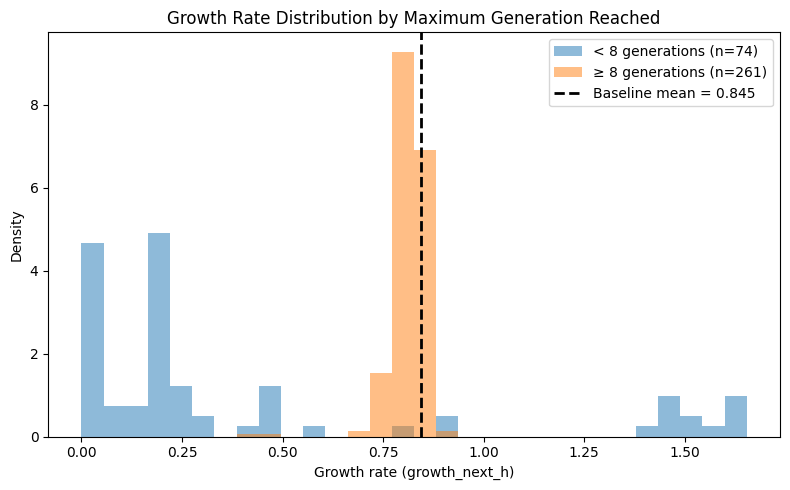

In [7]:
"""
Plot the growth rate distribution comparing TUs that reached at least 8 generations
vs those that stopped before 8 generations (including NaN max_generation cases,
which indicate simulations that did not reach the 8th generation).

Reference for max generation:
    "max_generation" in
    /user/home/il22158/work/vEcoli/surrogate/results/default_KO/gene_knockout_generation_summary_operon_selective.csv

Reference for growth rate:
    "growth_next_h" in
    /user/home/il22158/work/vEcoli/surrogate/train_data/operon_level_training_dataset.csv

Matching columns:
    "operon_id" in the max generation file corresponds to "ko_operon_id" in the training dataset.

Processing steps:
    - Growth rates are aggregated by averaging over lineage_seed for the first two seeds to obtain operon-level values.
    - Baseline growth rates are averaged across seeds to provide a single reference value.
    - max_generation NaN values are treated as "< 8" group.
    - The baseline samples are plotted alongside the knockout groups.
    - A vertical line is used to indicate the baseline mean growth rate.
"""
import pandas as pd
import matplotlib.pyplot as plt

# Out
out_dir = "/user/home/il22158/work/vEcoli/surrogate/results/default_KO"

# Load data
gen_df = pd.read_csv(
    "/user/home/il22158/work/vEcoli/surrogate/results/default_KO/gene_knockout_generation_summary_operon_selective.csv"
)
train_df = pd.read_csv(
    "/user/home/il22158/work/vEcoli/surrogate/train_data/operon_level_training_dataset.csv"
)

# Operon-level max generation (KEEP NaNs)
gen_df = gen_df[["operon_id", "max_generation"]].drop_duplicates("operon_id")

# Growth preprocessing (unchanged)
baseline = train_df[train_df["run_type"] == "baseline"]

ko_df = train_df[train_df["run_type"] != "baseline"]

# keep only first two seeds per operon
ko_df = ko_df.sort_values(["ko_operon_id", "lineage_seed"])
ko_df = ko_df.groupby("ko_operon_id").head(2)

# average over those two seeds for each operon
ko_df = (
    ko_df.groupby("ko_operon_id", as_index=False)["growth_next_h"]
    .mean()
)

# baseline mean (average across also two seeds, as there are only seeds 100 and 101)
baseline_vals = baseline.groupby("lineage_seed", as_index=False)["growth_next_h"].mean()["growth_next_h"]
baseline_mean = baseline_vals.mean()

# merge (keep NaNs)
df = gen_df.merge(
    ko_df,
    left_on="operon_id",
    right_on="ko_operon_id",
    how="left"
)

print("Total operon IDs:", len(df))

# ---- FIX: NaNs belong to "< 8" group ----
stopped_before_8 = df.loc[
    (df["max_generation"] < 8) | (df["max_generation"].isna()),
    "growth_next_h"
]

reached_8_plus = df.loc[df["max_generation"] >= 8, "growth_next_h"]

# Shared bins
valid_vals = pd.concat([stopped_before_8, reached_8_plus, baseline_vals], ignore_index=True).dropna()
bins = 30
bin_range = (valid_vals.min(), valid_vals.max())

plt.figure(figsize=(8, 5))

plt.hist(stopped_before_8, bins=bins, range=bin_range, alpha=0.5, density=True,
         label=f"< 8 generations (n={len(stopped_before_8)})")

plt.hist(reached_8_plus, bins=bins, range=bin_range, alpha=0.5, density=True,
         label=f"≥ 8 generations (n={len(reached_8_plus)})")

# baseline reference line
plt.axvline(
    baseline_mean,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Baseline mean = {baseline_mean:.3f}"
)

plt.xlabel("Growth rate (growth_next_h)")
plt.ylabel("Density")
plt.title("Growth Rate Distribution by Maximum Generation Reached")
plt.legend()
plt.tight_layout()
plt.savefig(f"{out_dir}/growth_rate_distribution_operon_level.png")
plt.show()

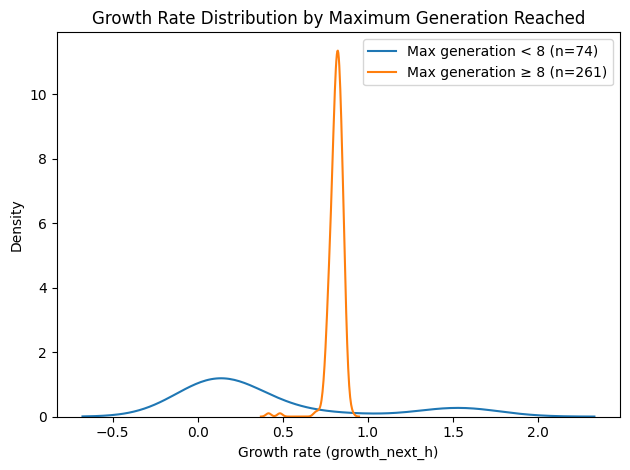

In [8]:
"""Alternative: KDE plot for smoother distribution comparison."""

import seaborn as sns

sns.kdeplot(stopped_before_8, label=f"Max generation < 8 (n={len(stopped_before_8)})")
sns.kdeplot(reached_8_plus, label=f"Max generation ≥ 8 (n={len(reached_8_plus)})")

plt.xlabel("Growth rate (growth_next_h)")
plt.ylabel("Density")
plt.title("Growth Rate Distribution by Maximum Generation Reached")
plt.legend()
plt.tight_layout()
plt.show()

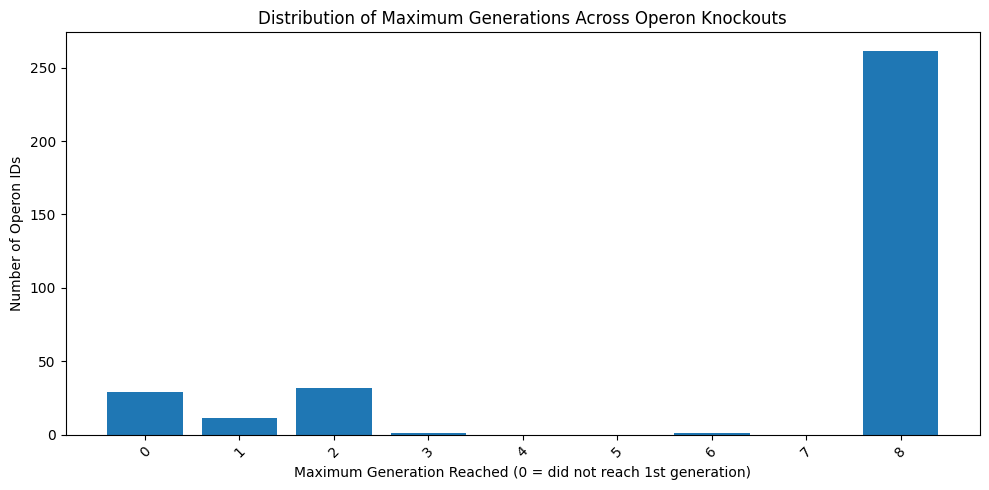

In [9]:
"""Inspect the max generation distribution across Operons only"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Count Operons at each maximum generation
gen_df["max_generation"] = gen_df["max_generation"].fillna(0)

gen_counts = (
    gen_df["max_generation"]
    .value_counts()
    .sort_index()
)

# Ensure 0 is included even if absent
all_gens = np.arange(0, gen_counts.index.max() + 1)
gen_counts = gen_counts.reindex(all_gens, fill_value=0)

# Plot
plt.figure(figsize=(10, 5))

plt.bar(gen_counts.index, gen_counts.values)

plt.xlabel("Maximum Generation Reached (0 = did not reach 1st generation)")
plt.ylabel("Number of Operon IDs")
plt.title("Distribution of Maximum Generations Across Operon Knockouts")

plt.xticks(gen_counts.index, rotation=45)
plt.tight_layout()
plt.show()

### Filtered training data - for the simulation failed to succeed to 8th generation take the growth rate as zero

In [14]:
"""Further filtering of training dataset: make the growth rate to zero for all samples where max_generation < 8. 
This is to reflect the fact that these lineages effectively failed to grow and should have zero growth rate, 
even if the measured growth_next_h is non-zero due to noise or short-term growth before collapse.
Save it to a new csv for data inspection."""
import pandas as pd

# Load data
gen_df = pd.read_csv(
    "/user/home/il22158/work/vEcoli/surrogate/results/default_KO/gene_knockout_generation_summary_operon_selective.csv"
)
train_df = pd.read_csv(
    "/user/home/il22158/work/vEcoli/surrogate/train_data/operon_level_training_dataset.csv"
)

# Operon-level max generation (keep NaN)
gen_df = gen_df[["operon_id", "max_generation"]].drop_duplicates("operon_id")

# Merge
df = train_df.merge(
    gen_df,
    left_on="ko_operon_id",
    right_on="operon_id",
    how="left"
)

# ---- IMPORTANT: separate baseline ----
baseline_mask = df["ko_operon_id"] == "baseline"

# Apply rule ONLY to KO samples
ko_mask = ~baseline_mask
filtered_mask = ko_mask & (df["max_generation"] < 8)
missing_mask = ko_mask & df["max_generation"].isna()
zeroed_mask = filtered_mask | missing_mask

df.loc[zeroed_mask, "growth_next_h"] = 0

# Clean helper column
df = df.drop(columns=["operon_id"])

# Save
output_path = "/user/home/il22158/work/vEcoli/surrogate/train_data/operon_level_training_dataset_growth_filtered.csv"
df.to_csv(output_path, index=False)

print(f"Saved: {output_path}")
print("Rows zeroed:", zeroed_mask.sum())
print("Rows still nonzero after filtering:", (zeroed_mask & (df["growth_next_h"] != 0)).sum())

Saved: /user/home/il22158/work/vEcoli/surrogate/train_data/operon_level_training_dataset_growth_filtered.csv
Rows zeroed: 212
Rows still nonzero after filtering: 0


Total operon IDs: 335


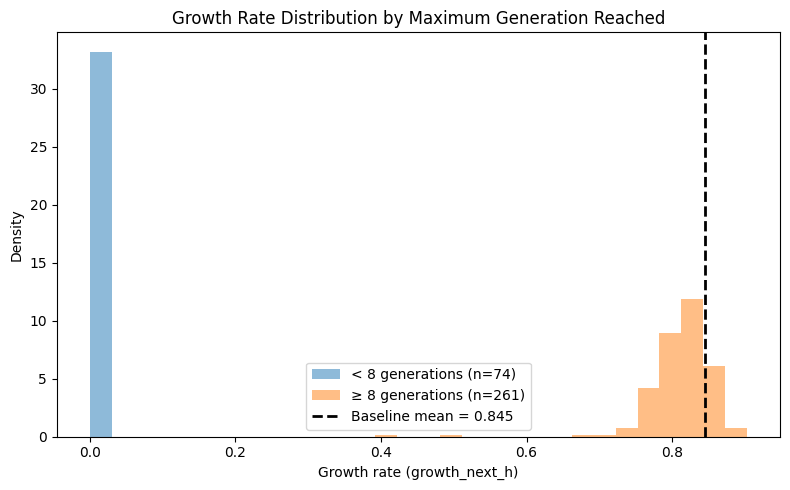

In [15]:
"""
Plot the growth rate distribution comparing TUs that reached at least 8 generations
vs those that stopped before 8 generations (including NaN max_generation cases,
which indicate simulations that did not reach the 8th generation).

Reference for max generation:
    "max_generation" in
    /user/home/il22158/work/vEcoli/surrogate/results/default_KO/gene_knockout_generation_summary_operon_selective.csv

Reference for growth rate:
    "growth_next_h" in
    /user/home/il22158/work/vEcoli/surrogate/train_data/operon_level_training_dataset.csv

Matching columns:
    "operon_id" in the max generation file corresponds to "ko_operon_id" in the training dataset.

Processing steps:
    - Growth rates are aggregated by averaging over lineage_seed for the first two seeds to obtain operon-level values.
    - Baseline growth rates are averaged across seeds to provide a single reference value.
    - max_generation NaN values are treated as "< 8" group.
    - The baseline samples are plotted alongside the knockout groups.
    - A vertical line is used to indicate the baseline mean growth rate.
"""
import pandas as pd
import matplotlib.pyplot as plt

# Out
out_dir = "/user/home/il22158/work/vEcoli/surrogate/results/default_KO"

# Load data
gen_df = pd.read_csv(
    "/user/home/il22158/work/vEcoli/surrogate/results/default_KO/gene_knockout_generation_summary_operon_selective.csv"
)
train_df = pd.read_csv(
    "/user/home/il22158/work/vEcoli/surrogate/train_data/operon_level_training_dataset_growth_filtered.csv"
)

# Operon-level max generation (KEEP NaNs)
gen_df = gen_df[["operon_id", "max_generation"]].drop_duplicates("operon_id")

# Growth preprocessing (unchanged)
baseline = train_df[train_df["run_type"] == "baseline"]

ko_df = train_df[train_df["run_type"] != "baseline"]

# keep only first two seeds per operon
ko_df = ko_df.sort_values(["ko_operon_id", "lineage_seed"])
ko_df = ko_df.groupby("ko_operon_id").head(2)

# average over those two seeds for each operon
ko_df = (
    ko_df.groupby("ko_operon_id", as_index=False)["growth_next_h"]
    .mean()
)

# baseline mean (average across also two seeds, as there are only seeds 100 and 101)
baseline_vals = baseline.groupby("lineage_seed", as_index=False)["growth_next_h"].mean()["growth_next_h"]
baseline_mean = baseline_vals.mean()

# merge (keep NaNs)
df = gen_df.merge(
    ko_df,
    left_on="operon_id",
    right_on="ko_operon_id",
    how="left"
)

print("Total operon IDs:", len(df))

# ---- FIX: NaNs belong to "< 8" group ----
stopped_before_8 = df.loc[
    (df["max_generation"] < 8) | (df["max_generation"].isna()),
    "growth_next_h"
]

reached_8_plus = df.loc[df["max_generation"] >= 8, "growth_next_h"]

# Shared bins
valid_vals = pd.concat([stopped_before_8, reached_8_plus, baseline_vals], ignore_index=True).dropna()
bins = 30
bin_range = (valid_vals.min(), valid_vals.max())

plt.figure(figsize=(8, 5))

plt.hist(stopped_before_8, bins=bins, range=bin_range, alpha=0.5, density=True,
         label=f"< 8 generations (n={len(stopped_before_8)})")

plt.hist(reached_8_plus, bins=bins, range=bin_range, alpha=0.5, density=True,
         label=f"≥ 8 generations (n={len(reached_8_plus)})")

# baseline reference line
plt.axvline(
    baseline_mean,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Baseline mean = {baseline_mean:.3f}"
)

plt.xlabel("Growth rate (growth_next_h)")
plt.ylabel("Density")
plt.title("Growth Rate Distribution by Maximum Generation Reached")
plt.legend()
plt.tight_layout()
plt.savefig(f"{out_dir}/growth_rate_distribution_operon_level_filtered.png")
plt.show()

/tmp/ipykernel_1462005/413361357.py:3: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(stopped_before_8, label=f"Max generation < 8 (n={len(stopped_before_8)})")


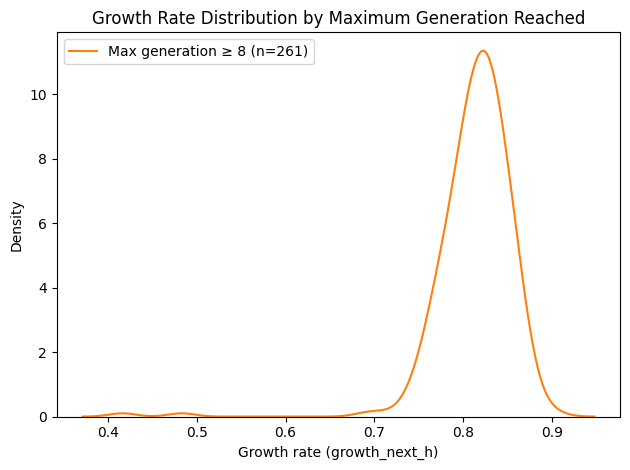

In [16]:
import seaborn as sns

sns.kdeplot(stopped_before_8, label=f"Max generation < 8 (n={len(stopped_before_8)})")
sns.kdeplot(reached_8_plus, label=f"Max generation ≥ 8 (n={len(reached_8_plus)})")

plt.xlabel("Growth rate (growth_next_h)")
plt.ylabel("Density")
plt.title("Growth Rate Distribution by Maximum Generation Reached")
plt.legend()
plt.tight_layout()
plt.show()

### Filtering training dataset - so only unique TU IDs and seeds are kept

In [18]:
import pandas as pd
from pathlib import Path

input_file = Path(
    "/user/home/il22158/work/vEcoli/surrogate/train_data/"
    "operon_level_training_dataset_growth_filtered.csv"
)

output_file = input_file.with_name(
    input_file.stem + "2.csv"
)

# Load dataset
df = pd.read_csv(input_file)

# Keep first occurrence of each operon ID + seed combination
df_trimmed = df.drop_duplicates(
    subset=["ko_operon_id", "lineage_seed"],
    keep="first"
)

# Save
df_trimmed.to_csv(output_file, index=False)

print(f"Original rows: {len(df)}")
print(f"Trimmed rows: {len(df_trimmed)}")
print(f"Saved to: {output_file}")

Original rows: 796
Trimmed rows: 698
Saved to: /user/home/il22158/work/vEcoli/surrogate/train_data/operon_level_training_dataset_growth_filtered2.csv


# Data preparation - default KO data - operon level

## load pq files and check data format

In [ ]:
import pandas as pd

file_path = "/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_gene_knockout_102trails_seed100_all.parquet"

df = pd.read_parquet(file_path)

print("=" * 80)
print("Shape:")
print(df.shape)

print("\n" + "=" * 80)
print("Columns:")
for col in df.columns:
    print(col)

print("\n" + "=" * 80)
print("Data types:")
print(df.dtypes)

print("\n" + "=" * 80)
print("First 5 rows:")
print(df.head())

Shape:
(63482, 6)

Columns:
project
variant
label
time
listeners__mass__instantaneous_growth_rate
listeners__mass__dry_mass

Data types:
project                                        object
variant                                         int64
label                                          object
time                                          float64
listeners__mass__instantaneous_growth_rate    float64
listeners__mass__dry_mass                     float64
dtype: object

First 5 rows:
                      project  variant     label  time  \
0  gene_knockout_3_round_test        0  baseline   0.0   
1  gene_knockout_3_round_test        0  baseline  20.0   
2  gene_knockout_3_round_test        0  baseline  40.0   
3  gene_knockout_3_round_test        0  baseline  60.0   
4  gene_knockout_3_round_test        0  baseline  80.0   

   listeners__mass__instantaneous_growth_rate  listeners__mass__dry_mass  
0                                    0.000000                 266.478760  
1          

In [ ]:
print("\n" + "=" * 80)
print("First 10 rows:") #read interval needs to be changed
print(df.head(20))


First 10 rows:
                       project  variant     label   time  \
0   gene_knockout_3_round_test        0  baseline    0.0   
1   gene_knockout_3_round_test        0  baseline   20.0   
2   gene_knockout_3_round_test        0  baseline   40.0   
3   gene_knockout_3_round_test        0  baseline   60.0   
4   gene_knockout_3_round_test        0  baseline   80.0   
5   gene_knockout_3_round_test        0  baseline  100.0   
6   gene_knockout_3_round_test        0  baseline  120.0   
7   gene_knockout_3_round_test        0  baseline  140.0   
8   gene_knockout_3_round_test        0  baseline  160.0   
9   gene_knockout_3_round_test        0  baseline  180.0   
10  gene_knockout_3_round_test        0  baseline  200.0   
11  gene_knockout_3_round_test        0  baseline  220.0   
12  gene_knockout_3_round_test        0  baseline  240.0   
13  gene_knockout_3_round_test        0  baseline  260.0   
14  gene_knockout_3_round_test        0  baseline  280.0   
15  gene_knockout_3_roun

## TU-level training data construction

### Double-check total unique TU ids

In [ ]:
import pandas as pd
import numpy as np

# ----------------------------
# Paths
# ----------------------------
summary_file = "/user/home/il22158/work/vEcoli/surrogate/results/default_KO/gene_knockout_generation_summary.csv"
mapping_file = "/user/home/il22158/work/vEcoli/surrogate/operon_classification.csv"

output_file = "/user/home/il22158/work/vEcoli/surrogate/results/default_KO/gene_knockout_generation_summary_TU_selective.csv"

# ----------------------------
# Load data
# ----------------------------
df = pd.read_csv(summary_file, engine="python")
map_df = pd.read_csv(mapping_file)

# ----------------------------
# Gene → TU mapping
# ----------------------------
gene_to_tu = dict(zip(map_df["id"], map_df["tu_id"]))
if "symbol" in map_df.columns:
    gene_to_tu.update(dict(zip(map_df["symbol"], map_df["tu_id"])))

# ----------------------------
# Only these projects need conversion
# ----------------------------
convert_projects = {
    "gene_knockout_p_list",
    "gene_knockout_leftover",
    "gene_knockout_3_round_test"
}

# ----------------------------
# Helper
# ----------------------------
def is_tu(x):
    return isinstance(x, str) and x.startswith("TU")

def convert_if_needed(row):
    val = row["gene_knockout"]
    project = row["project_name"]

    if pd.isna(val):
        return val

    val = str(val).strip()

    # Only convert selected projects
    if project in convert_projects:
        if is_tu(val):
            return val
        return gene_to_tu.get(val, np.nan)

    # otherwise keep original
    return val

# ----------------------------
# Apply conversion
# ----------------------------
df["TU_id"] = df.apply(convert_if_needed, axis=1)

# ----------------------------
# Diagnostics
# ----------------------------
missing = df[df["TU_id"].isna()]["gene_knockout"].unique()

print("Unmapped values:", len(missing))
print(missing[:20])

# ----------------------------
# Save
# ----------------------------
df.to_csv(output_file, index=False)

print("Saved:", output_file)

Unmapped values: 1
['baseline']
Saved: /user/home/il22158/work/vEcoli/surrogate/results/default_KO/gene_knockout_generation_summary_TU_selective.csv


In [ ]:
import pandas as pd

file_path = "/user/home/il22158/work/vEcoli/surrogate/results/default_KO/gene_knockout_generation_summary_TU_selective.csv"

df = pd.read_csv(file_path)

# count unique TU IDs (from conversion step)
unique_tu = df["TU_id"].nunique()

print("Unique TU IDs:", unique_tu)

Unique TU IDs: 350


In [ ]:
import pandas as pd

# Input (converted file)
input_file = "/user/home/il22158/work/vEcoli/surrogate/results/default_KO/gene_knockout_generation_summary_TU_selective.csv"

# Output file
output_file = "/user/home/il22158/work/vEcoli/surrogate/results/default_KO/gene_knockout_generation_summary_TU_grouped.csv"

# ----------------------------
# Load data
# ----------------------------
df = pd.read_csv(input_file)

# ----------------------------
# Ensure TU_id exists
# ----------------------------
df = df[df["TU_id"].notna()].copy()

# ----------------------------
# Count occurrences per TU
# ----------------------------
df["TU_count"] = df.groupby("TU_id")["TU_id"].transform("size")

# ----------------------------
# Sort by TU_id
# ----------------------------
df = df.sort_values(by="TU_id")

# ----------------------------
# Reorder columns (TU_id first)
# ----------------------------
cols = ["TU_id", "TU_count"] + [c for c in df.columns if c not in ["TU_id", "TU_count"]]
df = df[cols]

# ----------------------------
# Save
# ----------------------------
df.to_csv(output_file, index=False)

print("Saved:", output_file)
print("Unique TU IDs:", df["TU_id"].nunique())

Saved: /user/home/il22158/work/vEcoli/surrogate/results/default_KO/gene_knockout_generation_summary_TU_grouped.csv
Unique TU IDs: 350


### Training data construction

In [ ]:
"""TU-level training dataset construction"""

from pathlib import Path
import re
import numpy as np
import pandas as pd

# ============================
# PATHS
# ============================
BASE = Path("/user/home/il22158/work/vEcoli")
SURROGATE_DIR = BASE / "surrogate"
TRAIN_DIR = SURROGATE_DIR / "train_data"
TRAIN_DIR.mkdir(parents=True, exist_ok=True)

TIMESERIES_FILES = [
    BASE / "reading/results/growth_rate/growth_rate_timeseries_gene_knockout_102trails_seed100_all.parquet",
    BASE / "reading/results/growth_rate/growth_rate_timeseries_gene_knockout_102trails_seed101_all.parquet",
    BASE / "reading/results/growth_rate/growth_rate_timeseries_gene_knockout_leftover_seed101_all.parquet",
    BASE / "reading/results/growth_rate/growth_rate_timeseries_gene_knockout_leftover_seed100_all.parquet",
    BASE / "reading/results/growth_rate/growth_rate_timeseries_gene_knockout_TU_ID_rest_list_rerun12_seed10_all.parquet",
    BASE / "reading/results/growth_rate/growth_rate_timeseries_gene_knockout_TU_ID_rest_list_rerun12_seed11_all.parquet",
]

SUMMARY_FILES = [
    BASE / "reading/results/growth_rate/growth_rate_summary_gene_knockout_TU_ID_rest_list_rerun12_seed11_all.csv",
    BASE / "reading/results/growth_rate/growth_rate_summary_gene_knockout_TU_ID_rest_list_rerun12_seed10_all.csv",
    BASE / "reading/results/growth_rate/growth_rate_summary_gene_knockout_leftover_seed101_all.csv",
    BASE / "reading/results/growth_rate/growth_rate_summary_gene_knockout_leftover_seed100_all.csv",
    BASE / "reading/results/growth_rate/growth_rate_summary_gene_knockout_102trails_seed101_all.csv",
    BASE / "reading/results/growth_rate/growth_rate_summary_gene_knockout_102trails_seed100_all.csv",
]

TU_GROUP_FILE = BASE / "surrogate/results/default_KO/gene_knockout_generation_summary_TU_grouped.csv"


# ============================
# HELPERS
# ============================
def infer_seed(path: Path) -> int:
    m = re.search(r"seed(\d+)", path.name)
    if not m:
        raise ValueError(f"No seed in {path}")
    return int(m.group(1))


def load_timeseries(path: Path) -> pd.DataFrame:
    df = pd.read_parquet(path)

    required = {
        "project",
        "variant",
        "label",
        "time",
        "listeners__mass__instantaneous_growth_rate",
        "listeners__mass__dry_mass",
    }
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{path} missing columns {missing}")

    df = df.copy()
    df["source_file"] = path.name
    df["lineage_seed"] = infer_seed(path)

    df["project"] = df["project"].astype(str)
    df["variant"] = pd.to_numeric(df["variant"], errors="coerce").astype("Int64")
    df["label"] = df["label"].astype("string")
    df["time"] = pd.to_numeric(df["time"], errors="coerce")

    df["listeners__mass__instantaneous_growth_rate"] = pd.to_numeric(
        df["listeners__mass__instantaneous_growth_rate"], errors="coerce"
    )
    df["listeners__mass__dry_mass"] = pd.to_numeric(
        df["listeners__mass__dry_mass"], errors="coerce"
    )

    return df


def load_summary(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)

    required = {
        "project",
        "variant",
        "label",
        "mean_growth_rate",
        "median_growth_rate",
        "std_growth_rate",
        "max_growth_rate",
        "initial_dry_mass",
        "final_dry_mass",
        "max_dry_mass",
        "fold_change_mass",
        "duration_sec",
        "n_timepoints",
        "generations_used",
    }

    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{path} missing columns {missing}")

    df = df.copy()
    df["source_file"] = path.name
    df["lineage_seed"] = infer_seed(path)

    df["project"] = df["project"].astype(str)
    df["variant"] = pd.to_numeric(df["variant"], errors="coerce").astype("Int64")
    df["label"] = df["label"].astype("string")

    for c in required - {"project", "variant", "label"}:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    return df


# ============================
# LOAD DATA
# ============================
timeseries_df = pd.concat([load_timeseries(p) for p in TIMESERIES_FILES], ignore_index=True)
summary_df = pd.concat([load_summary(p) for p in SUMMARY_FILES], ignore_index=True)


# ============================
# TU REFERENCE (350 FIXED)
# ============================
tu_map = pd.read_csv(TU_GROUP_FILE).dropna(subset=["TU_id"])

ALL_TU_IDS = sorted(tu_map["TU_id"].astype(str).unique().tolist())

print("TU universe size (must be 350):", len(ALL_TU_IDS))
assert len(ALL_TU_IDS) == 350, "TU reference is not 350"


gene_to_tu = dict(zip(
    tu_map["gene_knockout"].astype(str),
    tu_map["TU_id"].astype(str)
))


# ============================
# CORRECT LABEL PARSER
# ============================
def extract_gene(label):
    if pd.isna(label):
        return pd.NA
    s = str(label)

    if s == "baseline":
        return "baseline"

    m = re.search(r"KO:([^,]+)", s)
    if m:
        return m.group(1).strip()

    return s.strip()


def to_tu(x):
    if pd.isna(x):
        return pd.NA

    x = str(x).strip()

    if x == "baseline":
        return "baseline"

    if x.startswith("TU"):
        return x

    return gene_to_tu.get(x, pd.NA)


# ============================
# APPLY MAPPING
# ============================
summary_df = summary_df.sort_values(
    ["lineage_seed", "project", "variant", "label"]
).reset_index(drop=True)

summary_df["gene_extracted"] = summary_df["label"].apply(extract_gene)
summary_df["ko_tu_id"] = summary_df["gene_extracted"].apply(to_tu)

summary_df["run_type"] = np.where(summary_df["label"].astype(str).eq("baseline"), "baseline", "KO")

# ============================
# DEBUG OUTPUT (IMPORTANT)
# ============================
debug_csv = TRAIN_DIR / "TU_mapping_debug.csv"
summary_df.to_csv(debug_csv, index=False)

print("DEBUG CSV saved:", debug_csv)

unmapped_count = summary_df["ko_tu_id"].isna().sum()
print("Unmapped rows:", unmapped_count)


# ============================
# FEATURE SPACE (STRICT 350)
# ============================
tu_onehot = pd.get_dummies(summary_df["ko_tu_id"], dtype=np.int8)

tu_onehot = tu_onehot.reindex(columns=ALL_TU_IDS, fill_value=0)

tu_onehot.columns = [f"tu_available__{c}" for c in tu_onehot.columns]

tu_available = (1 - tu_onehot).astype(np.int8)

print("Feature dimension:", tu_available.shape[1])
assert tu_available.shape[1] == 350


# ============================
# TARGET VARIABLES
# ============================
summary_df["growth_next_h"] = summary_df["mean_growth_rate"].astype(float) * 3600.0
summary_df["current_growth_h"] = summary_df["growth_next_h"]
summary_df["current_dry_mass_g"] = summary_df["initial_dry_mass"].astype(float)

summary_df["sample_id"] = (
    summary_df["project"].astype(str)
    + "|v" + summary_df["variant"].astype(str)
    + "|s" + summary_df["lineage_seed"].astype(str)
    + "|" + summary_df["label"].astype(str)
)


# ============================
# FINAL DATASET
# ============================
training_data = pd.concat(
    [
        summary_df[
            [
                "sample_id",
                "source_file",
                "lineage_seed",
                "project",
                "variant",
                "label",
                "run_type",
                "ko_tu_id",
                "mean_growth_rate",
                "median_growth_rate",
                "std_growth_rate",
                "max_growth_rate",
                "initial_dry_mass",
                "final_dry_mass",
                "max_dry_mass",
                "fold_change_mass",
                "duration_sec",
                "n_timepoints",
                "generations_used",
                "growth_next_h",
                "current_growth_h",
                "current_dry_mass_g",
            ]
        ].reset_index(drop=True),
        tu_available.reset_index(drop=True),
    ],
    axis=1,
)


# ============================
# SAVE OUTPUTS
# ============================
out_parquet = TRAIN_DIR / "TU_level_training_dataset.parquet"
out_csv = TRAIN_DIR / "TU_level_training_dataset.csv"

training_data.to_parquet(out_parquet, index=False)
training_data.to_csv(out_csv, index=False)

summary_df.to_csv(TRAIN_DIR / "TU_summary_debug.csv", index=False)
timeseries_df.to_parquet(TRAIN_DIR / "TU_timeseries.parquet", index=False)

pd.DataFrame({"feature_name": tu_available.columns}).to_csv(
    TRAIN_DIR / "TU_feature_list.csv",
    index=False
)


# ============================
# FINAL CHECKS
# ============================
print("\n==== FINAL REPORT ====")
print("Rows:", len(training_data))
print("TU universe:", len(ALL_TU_IDS))
print("Unmapped labels:", unmapped_count)
print("Feature dimension:", tu_available.shape[1])
print("Saved:", out_parquet)

TU universe size (must be 350): 350
DEBUG CSV saved: /user/home/il22158/work/vEcoli/surrogate/train_data/TU_mapping_debug.csv
Unmapped rows: 0
Feature dimension: 350

==== FINAL REPORT ====
Rows: 796
TU universe: 350
Unmapped labels: 0
Feature dimension: 350
Saved: /user/home/il22158/work/vEcoli/surrogate/train_data/TU_level_training_dataset.parquet


**TU-Level Training Dataset Construction**

1. Function and Data Flow

This pipeline constructs a machine learning training dataset from WholeCell gene knockout simulations while representing perturbations at the transcription unit (TU) level.

Workflow

1. Load all growth-rate time-series parquet files and summary CSV files.
2. Combine the data into unified time-series and summary datasets.
3. Parse simulation labels to identify:

   * Baseline simulations
   * Gene knockouts
   * TU knockouts
4. Use the TU reference file (`gene_knockout_generation_summary_TU_grouped.csv`) to:

   * Define the complete TU feature space (350 TUs)
   * Map gene knockouts to their corresponding TU IDs
5. Generate a binary TU feature matrix where:

   * `1` = TU available
   * `0` = TU knocked out
6. Create the final training dataset by combining:

   * Simulation metadata
   * Growth and biomass summary statistics
   * TU-level feature vectors
7. Save processed datasets and debugging outputs for downstream machine learning and validation.

---

2. Output Files

`TU_level_training_dataset.parquet`

Primary machine learning dataset in parquet format.

Contains:

* Simulation metadata
* Growth targets
* TU knockout identifiers
* 350 TU feature columns

Recommended file for model training.

`TU_level_training_dataset.csv`

CSV version of the training dataset for manual inspection and validation.

`TU_mapping_debug.csv`

Debugging file showing:

* Original simulation labels
* Extracted gene identifiers
* Assigned TU identifiers

Useful for checking mapping accuracy and identifying unmapped entries.

`TU_summary_debug.csv`

Combined summary dataset after preprocessing and TU mapping.

`TU_timeseries.parquet`

Combined time-series dataset containing all simulation trajectories.

Useful for:

* Recomputing summary statistics
* DTW analyses
* Additional feature engineering

`TU_feature_list.csv`

List of all TU feature names used in the final training dataset.

---

3. Expected Quantities

After successful execution, the following values are expected:

| Quantity            | Expected Value |
| ------------------- | -------------- |
| Total training rows | 796            |
| Baseline rows       | 6              |
| Knockout rows       | 790            |
| TU universe size    | 350            |
| TU feature count    | 350            |

The TU feature space should always be defined by the TU reference file and contain exactly 350 unique TU IDs.


### Raw aggragated growth rate data inspection

Total TU IDs: 350


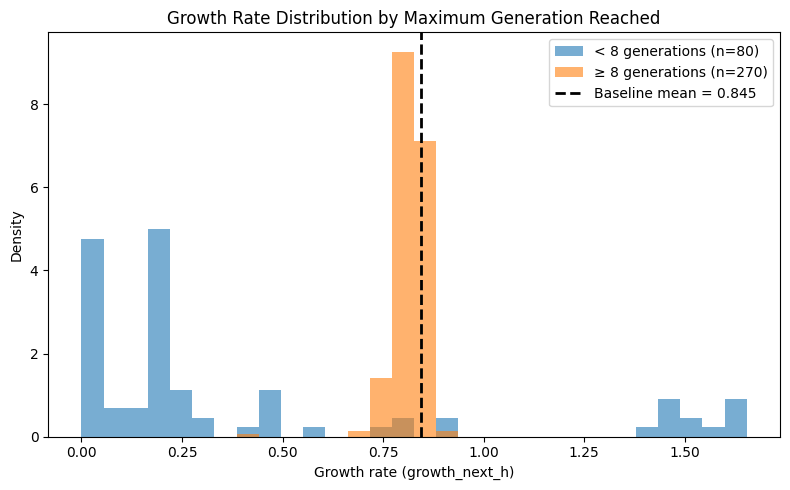

In [ ]:
"""
Plot the growth rate distribution comparing TUs that reached at least 8 generations
vs those that stopped before 8 generations (including NaN max_generation cases,
which indicate simulations that did not reach the 8th generation).

Reference for max generation:
    "max_generation" in
    /user/home/il22158/work/vEcoli/surrogate/results/default_KO/gene_knockout_generation_summary_TU_grouped.csv

Reference for growth rate:
    "growth_next_h" in
    /user/home/il22158/work/vEcoli/surrogate/train_data/TU_level_training_dataset.csv

Matching columns:
    "TU_id" in the max generation file corresponds to "ko_tu_id" in the training dataset.

Processing steps:
    - Growth rates are aggregated by averaging over lineage_seed for the first two seeds to obtain TU-level values.
    - Baseline growth rates are averaged across seeds to provide a single reference value.
    - max_generation NaN values are treated as "< 8 generations" group.
    - A vertical line is used to indicate the baseline mean growth rate.
"""
import pandas as pd
import matplotlib.pyplot as plt

# Out
out_dir = "/user/home/il22158/work/vEcoli/surrogate/results/default_KO"

# Load data
gen_df = pd.read_csv(
    "/user/home/il22158/work/vEcoli/surrogate/results/default_KO/gene_knockout_generation_summary_TU_grouped.csv"
)
train_df = pd.read_csv(
    "/user/home/il22158/work/vEcoli/surrogate/train_data/TU_level_training_dataset.csv"
)

# TU-level max generation (KEEP NaNs)
gen_df = gen_df[["TU_id", "max_generation"]].drop_duplicates("TU_id")

# Growth preprocessing (unchanged)
baseline = train_df[train_df["ko_tu_id"] == "baseline"]

ko_df = train_df[train_df["ko_tu_id"] != "baseline"]

# keep only first two seeds per TU
ko_df = ko_df.sort_values(["ko_tu_id", "lineage_seed"])

ko_df = ko_df.groupby("ko_tu_id").head(2)

# average over those two seeds for each TU
ko_df = (
    ko_df.groupby("ko_tu_id", as_index=False)["growth_next_h"]
    .mean()
)

# baseline mean (average across also two seeds, as there are only seeds 100 and 101)
baseline_mean = baseline.groupby("lineage_seed")["growth_next_h"].mean().mean()

# merge (keep NaNs)
df = gen_df.merge(
    ko_df,
    left_on="TU_id",
    right_on="ko_tu_id",
    how="left"
)

print("Total TU IDs:", len(df))

# ---- FIX: NaNs belong to "< 8" group ----
stopped_before_8 = df.loc[
    (df["max_generation"] < 8) | (df["max_generation"].isna()),
    "growth_next_h"
]

reached_8_plus = df.loc[df["max_generation"] >= 8, "growth_next_h"]

# Shared bins
valid_vals = df["growth_next_h"].dropna()
bins = 30
bin_range = (valid_vals.min(), valid_vals.max())

plt.figure(figsize=(8, 5))

plt.hist(stopped_before_8, bins=bins, range=bin_range, alpha=0.6, density=True,
         label=f"< 8 generations (n={len(stopped_before_8)})")

plt.hist(reached_8_plus, bins=bins, range=bin_range, alpha=0.6, density=True,
         label=f"≥ 8 generations (n={len(reached_8_plus)})")

# baseline reference line
plt.axvline(
    baseline_mean,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Baseline mean = {baseline_mean:.3f}"
)

plt.xlabel("Growth rate (growth_next_h)")
plt.ylabel("Density")
plt.title("Growth Rate Distribution by Maximum Generation Reached")
plt.legend()
plt.tight_layout()
plt.savefig(out_dir + "/growth_rate_distribution_TU_level.png")
plt.show()

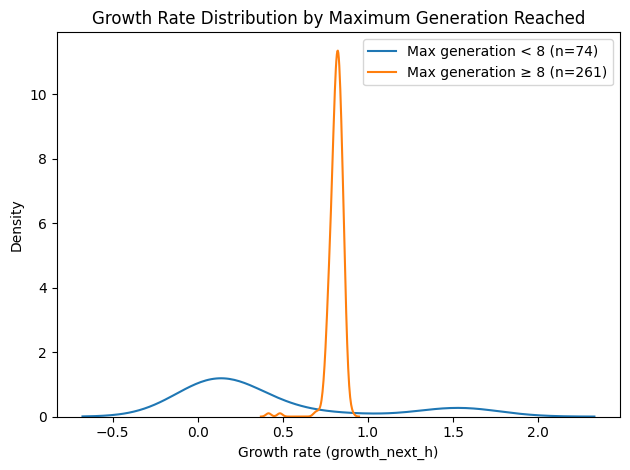

In [ ]:
"""Alternative: KDE plot for smoother distribution comparison."""

import seaborn as sns

sns.kdeplot(stopped_before_8, label=f"Max generation < 8 (n={len(stopped_before_8)})")
sns.kdeplot(reached_8_plus, label=f"Max generation ≥ 8 (n={len(reached_8_plus)})")

plt.xlabel("Growth rate (growth_next_h)")
plt.ylabel("Density")
plt.title("Growth Rate Distribution by Maximum Generation Reached")
plt.legend()
plt.tight_layout()
plt.show()

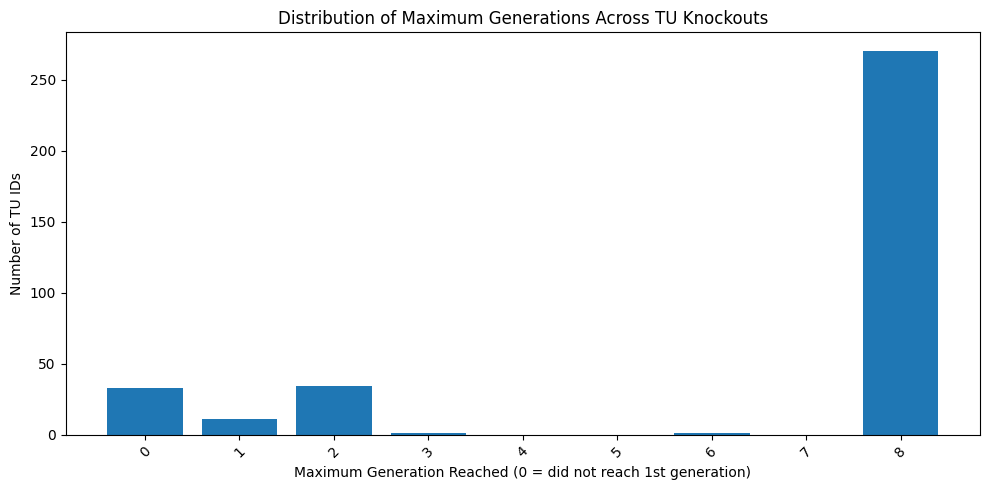

In [ ]:
"""Inspect the max generation distribution across TUs only"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Count TUs at each maximum generation
gen_df["max_generation"] = gen_df["max_generation"].fillna(0)

gen_counts = (
    gen_df["max_generation"]
    .value_counts()
    .sort_index()
)

# Ensure 0 is included even if absent
all_gens = np.arange(0, gen_counts.index.max() + 1)
gen_counts = gen_counts.reindex(all_gens, fill_value=0)

# Plot
plt.figure(figsize=(10, 5))

plt.bar(gen_counts.index, gen_counts.values)

plt.xlabel("Maximum Generation Reached (0 = did not reach 1st generation)")
plt.ylabel("Number of TU IDs")
plt.title("Distribution of Maximum Generations Across TU Knockouts")

plt.xticks(gen_counts.index, rotation=45)
plt.tight_layout()
plt.show()

### Filtered training data - for the simulation failed to succeed to 8th generation take the growth rate as zero

In [ ]:
"""Further filtering of training dataset: make the growth rate to zero for all samples where max_generation < 8. 
This is to reflect the fact that these lineages effectively failed to grow and should have zero growth rate, 
even if the measured growth_next_h is non-zero due to noise or short-term growth before collapse.
Save it to a new csv for data inspection."""
import pandas as pd

# Load data
gen_df = pd.read_csv(
    "/user/home/il22158/work/vEcoli/surrogate/results/default_KO/gene_knockout_generation_summary_TU_grouped.csv"
)
train_df = pd.read_csv(
    "/user/home/il22158/work/vEcoli/surrogate/train_data/TU_level_training_dataset.csv"
)

# TU-level max generation (keep NaN)
gen_df = gen_df[["TU_id", "max_generation"]].drop_duplicates("TU_id")

# Merge
df = train_df.merge(
    gen_df,
    left_on="ko_tu_id",
    right_on="TU_id",
    how="left"
)

# ---- IMPORTANT: separate baseline ----
baseline_mask = df["ko_tu_id"] == "baseline"

# Apply rule ONLY to KO samples
ko_mask = ~baseline_mask

df.loc[ko_mask & (df["max_generation"] < 8), "growth_next_h"] = 0
df.loc[ko_mask & (df["max_generation"].isna()), "growth_next_h"] = 0

# baseline stays untouched (no modification)

# Clean helper column
df = df.drop(columns=["TU_id"])

# Save
output_path = "/user/home/il22158/work/vEcoli/surrogate/train_data/TU_level_training_dataset_growth_filtered.csv"
df.to_csv(output_path, index=False)

print(f"Saved: {output_path}")
print("Baseline preserved:", df.loc[baseline_mask, "growth_next_h"].describe())

Saved: /user/home/il22158/work/vEcoli/surrogate/train_data/TU_level_training_dataset_growth_filtered.csv
Baseline preserved: count    6.000000
mean     0.845027
std      0.060865
min      0.803330
25%      0.803330
50%      0.808305
75%      0.895905
max      0.923446
Name: growth_next_h, dtype: float64


Total operon IDs: 335


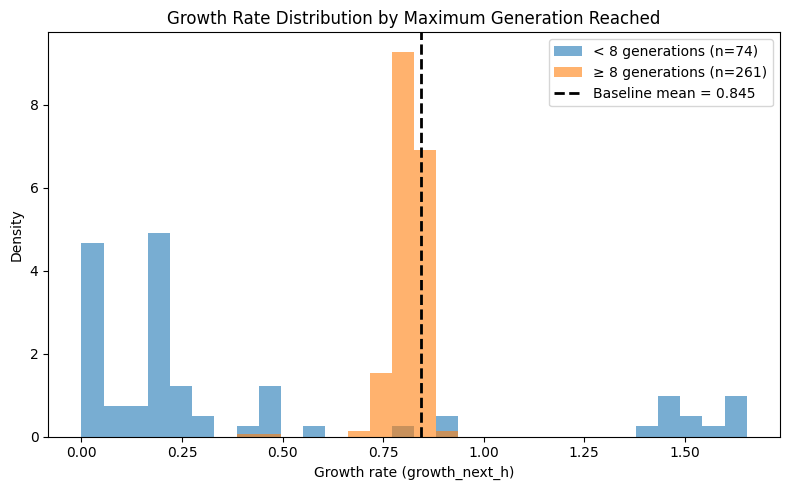

In [ ]:
"""
Plot the growth rate distribution comparing TUs that reached at least 8 generations
vs those that stopped before 8 generations (including NaN max_generation cases,
which indicate simulations that did not reach the 8th generation).

Reference for max generation:
    "max_generation" in
    /user/home/il22158/work/vEcoli/surrogate/results/default_KO/gene_knockout_generation_summary_TU_grouped.csv

Reference for growth rate:
    "growth_next_h" in
    /user/home/il22158/work/vEcoli/surrogate/train_data/TU_level_training_dataset_growth_filtered.csv

Matching columns:
    "TU_id" in the max generation file corresponds to "ko_tu_id" in the training dataset.

Processing steps:
    - Growth rates are aggregated by averaging over lineage_seed for the first two seeds to obtain TU-level values.
    - Baseline growth rates are averaged across seeds to provide a single reference value.
    - max_generation NaN values are treated as "< 8 generations" group.
    - A vertical line is used to indicate the baseline mean growth rate.
"""
import pandas as pd
import matplotlib.pyplot as plt

# Load data
gen_df = pd.read_csv(
    "/user/home/il22158/work/vEcoli/surrogate/results/default_KO/gene_knockout_generation_summary_TU_grouped.csv"
)
train_df = pd.read_csv(
    "/user/home/il22158/work/vEcoli/surrogate/train_data/TU_level_training_dataset_growth_filtered.csv"
)

# TU-level max generation (KEEP NaNs)
gen_df = gen_df[["TU_id", "max_generation"]].drop_duplicates("TU_id")

# Growth preprocessing (unchanged)
baseline = train_df[train_df["ko_tu_id"] == "baseline"]

ko_df = train_df[train_df["ko_tu_id"] != "baseline"]

# keep only first two seeds per TU
ko_df = ko_df.sort_values(["ko_tu_id", "lineage_seed"])

ko_df = ko_df.groupby("ko_tu_id").head(2)

# average over those two seeds for each TU
ko_df = (
    ko_df.groupby("ko_tu_id", as_index=False)["growth_next_h"]
    .mean()
)

# baseline mean (average across also two seeds, as there are only seeds 100 and 101)
baseline_mean = baseline.groupby("lineage_seed")["growth_next_h"].mean().mean()

# merge (keep NaNs)
df = gen_df.merge(
    ko_df,
    left_on="TU_id",
    right_on="ko_tu_id",
    how="left"
)

print("Total TU IDs:", len(df))

# ---- FIX: NaNs belong to "< 8" group ----
stopped_before_8 = df.loc[
    (df["max_generation"] < 8) | (df["max_generation"].isna()),
    "growth_next_h"
]

reached_8_plus = df.loc[df["max_generation"] >= 8, "growth_next_h"]

# Shared bins
valid_vals = df["growth_next_h"].dropna()
bins = 30
bin_range = (valid_vals.min(), valid_vals.max())

plt.figure(figsize=(8, 5))

plt.hist(stopped_before_8, bins=bins, range=bin_range, alpha=0.6, density=True,
         label=f"< 8 generations (n={len(stopped_before_8)})")

plt.hist(reached_8_plus, bins=bins, range=bin_range, alpha=0.6, density=True,
         label=f"≥ 8 generations (n={len(reached_8_plus)})")

# baseline reference line
plt.axvline(
    baseline_mean,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Baseline mean = {baseline_mean:.3f}"
)

plt.xlabel("Growth rate (growth_next_h)")
plt.ylabel("Density")
plt.title("Growth Rate Distribution by Maximum Generation Reached")
plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_2255063/413361357.py:3: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(stopped_before_8, label=f"Max generation < 8 (n={len(stopped_before_8)})")


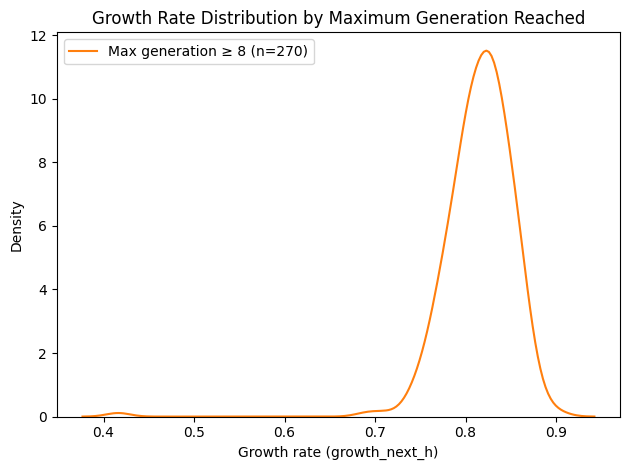

In [ ]:
import seaborn as sns

sns.kdeplot(stopped_before_8, label=f"Max generation < 8 (n={len(stopped_before_8)})")
sns.kdeplot(reached_8_plus, label=f"Max generation ≥ 8 (n={len(reached_8_plus)})")

plt.xlabel("Growth rate (growth_next_h)")
plt.ylabel("Density")
plt.title("Growth Rate Distribution by Maximum Generation Reached")
plt.legend()
plt.tight_layout()
plt.show()

### Filtering training dataset - so only unique TU IDs and seeds are kept

In [ ]:
import pandas as pd
from pathlib import Path

input_file = Path(
    "/user/home/il22158/work/vEcoli/surrogate/train_data/"
    "TU_level_training_dataset_growth_filtered.csv"
)

output_file = input_file.with_name(
    input_file.stem + "2.csv"
)

# Load dataset
df = pd.read_csv(input_file)

# Keep first occurrence of each TU ID + seed combination
df_trimmed = df.drop_duplicates(
    subset=["ko_tu_id", "lineage_seed"],
    keep="first"
)

# Save
df_trimmed.to_csv(output_file, index=False)

print(f"Original rows: {len(df)}")
print(f"Trimmed rows: {len(df_trimmed)}")
print(f"Saved to: {output_file}")

Original rows: 796
Trimmed rows: 724
Saved to: /user/home/il22158/work/vEcoli/surrogate/train_data/TU_level_training_dataset_growth_filtered2.csv


In [ ]:
"""TU-level training dataset construction (fixed 350-TU reference space)"""

from pathlib import Path
import re
import numpy as np
import pandas as pd

# ============================
# PATHS
# ============================
BASE = Path("/user/home/il22158/work/vEcoli")
SURROGATE_DIR = BASE / "surrogate"
TRAIN_DIR = SURROGATE_DIR / "train_data"
TRAIN_DIR.mkdir(parents=True, exist_ok=True)

TIMESERIES_FILES = [
    BASE / "reading/results/growth_rate/growth_rate_timeseries_gene_knockout_102trails_seed100_all.parquet",
    BASE / "reading/results/growth_rate/growth_rate_timeseries_gene_knockout_102trails_seed101_all.parquet",
    BASE / "reading/results/growth_rate/growth_rate_timeseries_gene_knockout_leftover_seed101_all.parquet",
    BASE / "reading/results/growth_rate/growth_rate_timeseries_gene_knockout_leftover_seed100_all.parquet",
    BASE / "reading/results/growth_rate/growth_rate_timeseries_gene_knockout_TU_ID_rest_list_rerun12_seed10_all.parquet",
    BASE / "reading/results/growth_rate/growth_rate_timeseries_gene_knockout_TU_ID_rest_list_rerun12_seed11_all.parquet",
]

SUMMARY_FILES = [
    BASE / "reading/results/growth_rate/growth_rate_summary_gene_knockout_TU_ID_rest_list_rerun12_seed11_all.csv",
    BASE / "reading/results/growth_rate/growth_rate_summary_gene_knockout_TU_ID_rest_list_rerun12_seed10_all.csv",
    BASE / "reading/results/growth_rate/growth_rate_summary_gene_knockout_leftover_seed101_all.csv",
    BASE / "reading/results/growth_rate/growth_rate_summary_gene_knockout_leftover_seed100_all.csv",
    BASE / "reading/results/growth_rate/growth_rate_summary_gene_knockout_102trails_seed101_all.csv",
    BASE / "reading/results/growth_rate/growth_rate_summary_gene_knockout_102trails_seed100_all.csv",
]

TU_GROUP_FILE = BASE / "surrogate/results/default_KO/gene_knockout_generation_summary_TU_grouped.csv"


# ============================
# HELPERS
# ============================
def infer_seed(path: Path) -> int:
    m = re.search(r"seed(\d+)", path.name)
    if not m:
        raise ValueError(f"No seed in {path}")
    return int(m.group(1))


def load_timeseries(path: Path) -> pd.DataFrame:
    df = pd.read_parquet(path)

    required = {
        "project",
        "variant",
        "label",
        "time",
        "listeners__mass__instantaneous_growth_rate",
        "listeners__mass__dry_mass",
    }
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{path} missing columns {missing}")

    df = df.copy()
    df["source_file"] = path.name
    df["lineage_seed"] = infer_seed(path)

    df["project"] = df["project"].astype(str)
    df["variant"] = pd.to_numeric(df["variant"], errors="coerce").astype("Int64")
    df["label"] = df["label"].astype("string")
    df["time"] = pd.to_numeric(df["time"], errors="coerce")

    df["listeners__mass__instantaneous_growth_rate"] = pd.to_numeric(
        df["listeners__mass__instantaneous_growth_rate"], errors="coerce"
    )
    df["listeners__mass__dry_mass"] = pd.to_numeric(
        df["listeners__mass__dry_mass"], errors="coerce"
    )

    return df


def load_summary(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)

    required = {
        "project",
        "variant",
        "label",
        "mean_growth_rate",
        "median_growth_rate",
        "std_growth_rate",
        "max_growth_rate",
        "initial_dry_mass",
        "final_dry_mass",
        "max_dry_mass",
        "fold_change_mass",
        "duration_sec",
        "n_timepoints",
        "generations_used",
    }

    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{path} missing columns {missing}")

    df = df.copy()
    df["source_file"] = path.name
    df["lineage_seed"] = infer_seed(path)

    df["project"] = df["project"].astype(str)
    df["variant"] = pd.to_numeric(df["variant"], errors="coerce").astype("Int64")
    df["label"] = df["label"].astype("string")

    for c in required - {"project", "variant", "label"}:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    return df


def summarize_timeseries(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    group_cols = ["source_file", "lineage_seed", "project", "variant", "label"]

    for keys, g in df.groupby(group_cols, dropna=False, sort=False):
        growth = g["listeners__mass__instantaneous_growth_rate"].to_numpy()
        mass = g["listeners__mass__dry_mass"].to_numpy()
        t = g["time"].to_numpy()

        rows.append(
            {
                "source_file": keys[0],
                "lineage_seed": keys[1],
                "project": keys[2],
                "variant": keys[3],
                "label": keys[4],
                "mean_growth_rate": float(np.mean(growth)),
                "median_growth_rate": float(np.median(growth)),
                "std_growth_rate": float(np.std(growth)),
                "max_growth_rate": float(np.max(growth)),
                "initial_dry_mass": float(mass[0]),
                "final_dry_mass": float(mass[-1]),
                "max_dry_mass": float(np.max(mass)),
                "fold_change_mass": float(mass[-1] / mass[0]),
                "duration_sec": float(t[-1] - t[0]),
                "n_timepoints": int(len(g)),
            }
        )

    return pd.DataFrame(rows)


# ============================
# LOAD DATA
# ============================
timeseries_df = pd.concat([load_timeseries(p) for p in TIMESERIES_FILES], ignore_index=True)
summary_df = pd.concat([load_summary(p) for p in SUMMARY_FILES], ignore_index=True)

# ============================
# TU REFERENCE (CRITICAL FIX)
# ============================
tu_map = pd.read_csv(TU_GROUP_FILE).dropna(subset=["TU_id"])

ALL_TU_IDS = sorted(tu_map["TU_id"].astype(str).unique().tolist())

print("TU universe size (must be 350):", len(ALL_TU_IDS))
assert len(ALL_TU_IDS) == 350, "TU reference is NOT 350 — check TU file"


gene_to_tu = dict(zip(
    tu_map["gene_knockout"].astype(str),
    tu_map["TU_id"].astype(str)
))


def to_tu(x):
    if pd.isna(x):
        return pd.NA
    x = str(x).strip()
    if x.startswith("TU"):
        return x
    return gene_to_tu.get(x, pd.NA)


# ============================
# APPLY TU MAPPING
# ============================
summary_df = summary_df.sort_values(
    ["lineage_seed", "project", "variant", "label"]
).reset_index(drop=True)

summary_df["ko_tu_id"] = summary_df["label"].apply(to_tu)
summary_df["run_type"] = np.where(summary_df["label"].astype(str).eq("baseline"), "baseline", "KO")

missing = summary_df["ko_tu_id"].isna().sum()
print("Unmapped labels:", missing)

# ============================
# TARGET VARIABLES
# ============================
summary_df["growth_next_h"] = summary_df["mean_growth_rate"].astype(float) * 3600.0
summary_df["current_growth_h"] = summary_df["growth_next_h"]
summary_df["current_dry_mass_g"] = summary_df["initial_dry_mass"].astype(float)

summary_df["sample_id"] = (
    summary_df["project"].astype(str)
    + "|v" + summary_df["variant"].astype(str)
    + "|s" + summary_df["lineage_seed"].astype(str)
    + "|" + summary_df["label"].astype(str)
)

# ============================
# TU FEATURE SPACE (FIXED TO 350)
# ============================
tu_onehot = pd.get_dummies(summary_df["ko_tu_id"], dtype=np.int8)

tu_onehot = tu_onehot.reindex(columns=ALL_TU_IDS, fill_value=0)

tu_onehot.columns = [f"tu_available__{c}" for c in tu_onehot.columns]

tu_available = (1 - tu_onehot).astype(np.int8)

# HARD CHECK
print("Feature dimension:", tu_available.shape[1])
assert tu_available.shape[1] == 350, "Feature space is NOT 350 TU IDs"

# ============================
# TRAINING DATA
# ============================
training_data = pd.concat(
    [
        summary_df[
            [
                "sample_id",
                "source_file",
                "lineage_seed",
                "project",
                "variant",
                "label",
                "run_type",
                "ko_tu_id",
                "mean_growth_rate",
                "median_growth_rate",
                "std_growth_rate",
                "max_growth_rate",
                "initial_dry_mass",
                "final_dry_mass",
                "max_dry_mass",
                "fold_change_mass",
                "duration_sec",
                "n_timepoints",
                "generations_used",
                "growth_next_h",
                "current_growth_h",
                "current_dry_mass_g",
            ]
        ].reset_index(drop=True),
        tu_available.reset_index(drop=True),
    ],
    axis=1,
)

# ============================
# SAVE
# ============================
out = TRAIN_DIR / "TU_level_training_dataset_FIXED.parquet"
training_data.to_parquet(out, index=False)

print("Saved:", out)
print("Rows:", len(training_data))
print("Unique TU IDs:", len(ALL_TU_IDS))

TU universe size (must be 350): 350
Unmapped labels: 796
Feature dimension: 350
Saved: /user/home/il22158/work/vEcoli/surrogate/train_data/TU_level_training_dataset_FIXED.parquet
Rows: 796
Unique TU IDs: 350


/user/home/il22158/work/vEcoli/surrogate/rest_tu_ids_to_test.csv

/user/home/il22158/work/vEcoli/surrogate/train_data/surrogate_gene_catalog.csv

In [ ]:
from pathlib import Path
import ast

import numpy as np
import pandas as pd

BASE = Path("/user/home/il22158/work/vEcoli")
SURROGATE_DIR = BASE / "surrogate"
TRAIN_DIR = SURROGATE_DIR / "train_data"
TRAIN_DIR.mkdir(parents=True, exist_ok=True)

SUMMARY_CSV = SURROGATE_DIR / "results/default_KO/gene_knockout_generation_summary.csv"
REST_TU_CSV = SURROGATE_DIR / "rest_tu_ids_to_test.csv"
CATALOG_CSV = SURROGATE_DIR / "train_data/surrogate_gene_catalog.csv"

summary_df = pd.read_csv(SUMMARY_CSV)
rest_tu_df = pd.read_csv(REST_TU_CSV)
gene_catalog = pd.read_csv(CATALOG_CSV)

summary_df["gene_knockout"] = summary_df["gene_knockout"].astype("string")
summary_df["project_name"] = summary_df["project_name"].astype("string")
summary_df["variant"] = pd.to_numeric(summary_df["variant"], errors="coerce").astype("Int64")
summary_df["seed"] = pd.to_numeric(summary_df["seed"], errors="coerce").astype("Int64")
summary_df["max_generation"] = pd.to_numeric(summary_df["max_generation"], errors="coerce")
summary_df["s_pq"] = summary_df["s_pq"].astype("string").str.lower().isin(["true", "1", "yes"])

catalog_gene_ids = sorted(gene_catalog["gene_id"].dropna().astype(str).str.strip().unique().tolist())
if not catalog_gene_ids:
    raise RuntimeError("No gene_id values found in surrogate_gene_catalog.csv")

rest_tu_df = rest_tu_df.rename(columns={"tu_id": "ko_target_id"})
rest_tu_df["ko_target_id"] = rest_tu_df["ko_target_id"].astype(str).str.strip()
rest_tu_map = (
    rest_tu_df[["ko_target_id", "genes_in_rest_gene_to_test"]]
    .dropna(subset=["ko_target_id"])
    .drop_duplicates("ko_target_id")
    .set_index("ko_target_id")["genes_in_rest_gene_to_test"]
    .to_dict()
)

gene_catalog["gene_id"] = gene_catalog["gene_id"].astype(str).str.strip()
gene_catalog["tu_id"] = gene_catalog["tu_id"].astype(str).str.strip()

by_tu_map = (
    gene_catalog.loc[gene_catalog["tu_id"].ne(""), ["tu_id", "gene_id"]]
    .drop_duplicates()
    .groupby("tu_id")["gene_id"]
    .apply(list)
    .to_dict()
)

def parse_rna_ids(value: object) -> list[str]:
    if pd.isna(value):
        return []
    text = str(value).strip()
    if not text:
        return []
    try:
        parsed = ast.literal_eval(text)
        if isinstance(parsed, list):
            return [str(x).strip() for x in parsed if str(x).strip()]
    except Exception:
        pass
    return [text]

rna_to_gene_map: dict[str, list[str]] = {}
for _, row in gene_catalog[["gene_id", "rna_ids"]].dropna(subset=["gene_id"]).iterrows():
    gid = str(row["gene_id"]).strip()
    for rid in parse_rna_ids(row.get("rna_ids")):
        keys = {rid, f"{rid}[c]", rid.replace("[c]", "")}
        for key in keys:
            if key not in rna_to_gene_map:
                rna_to_gene_map[key] = []
            if gid not in rna_to_gene_map[key]:
                rna_to_gene_map[key].append(gid)

catalog_gene_id_set = set(catalog_gene_ids)

def map_ko_target_to_gene_ids(ko_target: object) -> list[str]:
    if pd.isna(ko_target):
        return []
    text = str(ko_target).strip()
    if not text or text == "baseline":
        return []

    if text in rest_tu_map and pd.notna(rest_tu_map[text]):
        genes = [g.strip() for g in str(rest_tu_map[text]).split(",") if g.strip()]
        genes = [g for g in genes if g in catalog_gene_id_set]
        if genes:
            return sorted(set(genes))

    if text in catalog_gene_id_set:
        return [text]

    if text in by_tu_map:
        genes = [g for g in by_tu_map[text] if g in catalog_gene_id_set]
        if genes:
            return sorted(set(genes))

    if text in rna_to_gene_map:
        genes = [g for g in rna_to_gene_map[text] if g in catalog_gene_id_set]
        if genes:
            return sorted(set(genes))

    stripped = text.replace("[c]", "")
    if stripped in rna_to_gene_map:
        genes = [g for g in rna_to_gene_map[stripped] if g in catalog_gene_id_set]
        if genes:
            return sorted(set(genes))

    return []

summary_df["ko_target_id"] = summary_df["gene_knockout"].astype(str).str.strip()
summary_df["ko_gene_ids"] = summary_df["ko_target_id"].map(map_ko_target_to_gene_ids)
summary_df["ko_gene_count"] = summary_df["ko_gene_ids"].map(len)
summary_df["gene_id"] = summary_df["ko_gene_ids"].map(lambda ids: ids[0] if ids else pd.NA).astype("string")
summary_df["ko_gene_id"] = summary_df["gene_id"]
summary_df["run_type"] = np.where(summary_df["ko_target_id"].eq("baseline"), "baseline", "KO")

feature_names = [f"gene_available__{g}" for g in catalog_gene_ids]
genotype_available = pd.DataFrame(
    np.ones((len(summary_df), len(catalog_gene_ids)), dtype=np.int8),
    columns=feature_names,
    index=summary_df.index,
)

gene_to_col = {g: f"gene_available__{g}" for g in catalog_gene_ids}
for idx, ids in summary_df["ko_gene_ids"].items():
    for gid in ids:
        col = gene_to_col.get(gid)
        if col is not None:
            genotype_available.at[idx, col] = 0

summary_df["project"] = summary_df["project_name"].astype(str)
summary_df["lineage_seed"] = summary_df["seed"]
summary_df["label"] = np.where(summary_df["ko_target_id"].eq("baseline"), "baseline", "KO: " + summary_df["ko_target_id"].astype(str))
summary_df["source_file"] = "gene_knockout_generation_summary.csv"
summary_df["growth_next_h"] = summary_df["max_generation"].astype(float)
summary_df["current_growth_h"] = summary_df["growth_next_h"]
summary_df["current_dry_mass_g"] = pd.NA
summary_df["current_generation"] = 0
summary_df["target_generation"] = 1
summary_df["gen_step"] = 1
summary_df["peak_generation"] = pd.NA
summary_df["peak_censored"] = False
summary_df["is_pre_peak"] = True
summary_df["sample_id"] = (
    summary_df["project"].astype(str)
    + "|v"
    + summary_df["variant"].astype(str)
    + "|s"
    + summary_df["lineage_seed"].astype(str)
    + "|"
    + summary_df["ko_target_id"].astype(str)
)

training_data = pd.concat(
    [
        summary_df[
            [
                "sample_id",
                "source_file",
                "lineage_seed",
                "project",
                "variant",
                "label",
                "run_type",
                "gene_id",
                "ko_gene_id",
                "ko_target_id",
                "ko_gene_count",
                "max_generation",
                "s_pq",
                "current_generation",
                "target_generation",
                "gen_step",
                "current_growth_h",
                "growth_next_h",
                "current_dry_mass_g",
                "peak_generation",
                "peak_censored",
                "is_pre_peak",
            ]
        ].reset_index(drop=True),
        genotype_available.reset_index(drop=True),
    ],
    axis=1,
)

training_data["ko_gene_ids"] = summary_df["ko_gene_ids"].map(lambda ids: ",".join(ids) if ids else "")

baseline_ref = training_data.loc[training_data["run_type"].eq("baseline"), "growth_next_h"].reset_index(drop=True)
baseline_next_growth = baseline_ref.copy()

out_parquet = TRAIN_DIR / "default_ko_training_dataset_mapped.parquet"
out_csv = TRAIN_DIR / "default_ko_training_dataset_mapped.csv"
feature_list_csv = TRAIN_DIR / "default_ko_genotype_feature_list_mapped.csv"

training_data.to_parquet(out_parquet, index=False)
training_data.to_csv(out_csv, index=False)
pd.DataFrame({"feature_name": feature_names}).to_csv(feature_list_csv, index=False)

unmapped = training_data.loc[
    training_data["run_type"].eq("KO") & training_data["ko_gene_ids"].eq(""),
    "ko_target_id",
].drop_duplicates().sort_values()

print("Reconstructed default KO training_data with TU/RNA -> gene mapping")
print(f"Rows: {len(training_data)}")
print(f"KO rows: {int(training_data['run_type'].eq('KO').sum())}")
print(f"Baseline rows: {int(training_data['run_type'].eq('baseline').sum())}")
print(f"Gene feature count: {len(feature_names)}")
print(f"Unmapped KO targets: {len(unmapped)}")
if len(unmapped) > 0:
    print(unmapped.head(20).to_string(index=False))
print(f"Saved dataset: {out_parquet}")
print(f"Saved csv: {out_csv}")
print(f"Saved features: {feature_list_csv}")

Operon universe size: 334
Reconstructed default KO training_data with operon-based features
Rows: 731
KO rows: 725
Baseline rows: 6
Operon feature count: 334
Unmapped KO targets: 0
Saved dataset: /user/home/il22158/work/vEcoli/surrogate/train_data/default_ko_operon_training_dataset_FIXED.parquet
Saved csv: /user/home/il22158/work/vEcoli/surrogate/train_data/default_ko_operon_training_dataset_FIXED.csv
Saved features: /user/home/il22158/work/vEcoli/surrogate/train_data/default_ko_operon_feature_list.csv


In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd

BASE = Path("/user/home/il22158/work/vEcoli")
SURROGATE_DIR = BASE / "surrogate"
DEFAULT_KO_DIR = SURROGATE_DIR / "results/default_KO"
SUMMARY_CSV = DEFAULT_KO_DIR / "gene_knockout_generation_summary.csv"
ADJACENT_RISE_SCALE = 2.0

summary_df = pd.read_csv(SUMMARY_CSV)
summary_df["variant"] = pd.to_numeric(summary_df["variant"], errors="coerce").astype("Int64")
summary_df["seed"] = pd.to_numeric(summary_df["seed"], errors="coerce").astype("Int64")
summary_df["project_name"] = summary_df["project_name"].astype("string")
summary_df["gene_knockout"] = summary_df["gene_knockout"].astype("string")
summary_df["max_generation"] = pd.to_numeric(summary_df["max_generation"], errors="coerce").astype("Int64")
summary_df["s_pq"] = summary_df["s_pq"].astype("string").str.lower().isin(["true", "1", "yes"])
summary_df["succeeds_to_8"] = summary_df["max_generation"].ge(8)
summary_df["failed_before_8"] = summary_df["gene_knockout"].astype(str).ne("baseline") & ~summary_df["succeeds_to_8"]

default_df = summary_df.copy()
default_df["run_type"] = np.where(default_df["gene_knockout"].astype(str).eq("baseline"), "baseline", "KO")
default_df["gene_id"] = default_df["gene_knockout"].map(lambda value: pd.NA if pd.isna(value) or str(value).strip() == "baseline" else str(value).split(";", 1)[0].strip()).astype("string")
default_df["growth_next_h"] = pd.to_numeric(default_df["max_generation"], errors="coerce")
default_df["current_growth_h"] = default_df["growth_next_h"]
default_df["current_generation"] = 0
default_df["current_dry_mass_g"] = pd.NA
default_df["target_generation"] = 1
default_df["gen_step"] = 1
default_df["peak_generation"] = pd.NA
default_df["peak_censored"] = False
default_df["is_pre_peak"] = True
default_df["sample_id"] = default_df["project_name"].astype(str) + "|v" + default_df["variant"].astype(str) + "|s" + default_df["seed"].astype(str) + "|" + default_df["gene_knockout"].astype(str)

print("=== Default KO abnormality check ===")
print(f"Rows loaded: {len(default_df)}")
print(f"KO rows that do not succeed to generation 8: {int(default_df['failed_before_8'].sum())}")
print(f"KO rows succeeding to generation 8: {int((default_df['run_type'].eq('KO') & default_df['succeeds_to_8']).sum())}")

if bool(default_df['failed_before_8'].any()):
    cols = [c for c in ["project_name", "variant", "seed", "gene_knockout", "max_generation", "s_pq", "succeeds_to_8"] if c in default_df.columns]
    print(default_df.loc[default_df['failed_before_8'], cols].head(20).to_string(index=False))

if "training_data" in globals():
    training_df = training_data.copy()
    sort_cols = [c for c in ["source_file", "project", "variant", "lineage_seed", "label", "gene_id", "run_type", "current_generation"] if c in training_df.columns]
    if sort_cols:
        training_df = training_df.sort_values(sort_cols).copy()

    if {"growth_next_h", "current_growth_h"}.issubset(training_df.columns):
        next_growth = pd.to_numeric(training_df.get("growth_next_h"), errors="coerce")
        current_growth = pd.to_numeric(training_df.get("current_growth_h"), errors="coerce")
        custom_abnormal_mask = next_growth.notna() & current_growth.notna() & (next_growth > current_growth * ADJACENT_RISE_SCALE)
        print("\n=== Custom adjacent-rise check on training_data ===")
        print(f"Rows loaded: {len(training_df)}")
        print(f"Rows with next > {ADJACENT_RISE_SCALE:g} * current: {int(custom_abnormal_mask.sum())}")
        if bool(custom_abnormal_mask.any()):
            show_cols = [c for c in ["project", "variant", "lineage_seed", "label", "gene_id", "current_generation", "growth_next_h", "current_growth_h"] if c in training_df.columns]
            print(training_df.loc[custom_abnormal_mask, show_cols].head(20).to_string(index=False))

=== Default KO abnormality check ===
Rows loaded: 575
KO rows that do not succeed to generation 8: 83
KO rows succeeding to generation 8: 478
                       project_name  variant  seed gene_knockout  max_generation  s_pq  succeeds_to_8
gene_knockout_TU_ID_rest_list_rerun        6    10   TU0-1021[c]               1  True          False
gene_knockout_TU_ID_rest_list_rerun        6    11   TU0-1021[c]               1  True          False
gene_knockout_TU_ID_rest_list_rerun       25    10  TU0-13080[c]               2  True          False
gene_knockout_TU_ID_rest_list_rerun       25    11  TU0-13080[c]               2  True          False
gene_knockout_TU_ID_rest_list_rerun       28    10  TU0-13093[c]               2  True          False
gene_knockout_TU_ID_rest_list_rerun       28    11  TU0-13093[c]               2  True          False
gene_knockout_TU_ID_rest_list_rerun       31    10  TU0-13135[c]               1  True          False
gene_knockout_TU_ID_rest_list_rerun       

## Data Validity Check

In [ ]:
from pathlib import Path
import json

import pandas as pd
import pyarrow.parquet as pq

roots = [
    Path("/user/home/il22158/work/vEcoli/out/gene_knockout_TU_ID_rest_list_rerun2"),
    Path("/user/home/il22158/work/vEcoli/out/gene_knockout_TU_ID_rest_list_rerun"),
]
output_dir = Path("/user/home/il22158/work/vEcoli/surrogate/results/default_KO")
output_dir.mkdir(parents=True, exist_ok=True)

rest_tu_csv = Path("/user/home/il22158/work/vEcoli/surrogate/rest_tu_ids_to_test.csv")
rest_tu_df = pd.read_csv(rest_tu_csv)
rest_tu_df = rest_tu_df.rename(
    columns={
        "tu_id": "gene_knockout",
        "genes_in_rest_gene_to_test": "associated_genes",
        "n_genes_in_rest_gene_to_test": "associated_gene_total_numbers",
    }
)
rest_tu_df = rest_tu_df[["gene_knockout", "associated_genes", "associated_gene_total_numbers"]]

records = []

for root in roots:
    metadata_path = root / "variant_sim_data" / "metadata.json"
    if not metadata_path.exists():
        raise FileNotFoundError(f"Missing metadata file: {metadata_path}")

    with metadata_path.open() as handle:
        metadata = json.load(handle)

    variant_map = metadata.get("gene_knockout", {})
    project_name = root.name
    success_root = root / "success" / f"experiment_id={project_name}"

    for variant_key, variant_info in sorted(variant_map.items(), key=lambda item: int(item[0])):
        variant = int(variant_key)
        gene_knockout = ";".join(variant_info.get("genes_to_knockout", []))
        variant_dir = success_root / f"variant={variant}"
        seed_dirs = sorted(variant_dir.glob("lineage_seed=*"), key=lambda path: int(path.name.split("=", 1)[1]))

        if not seed_dirs:
            records.append(
                {
                    "gene_knockout": gene_knockout,
                    "variant": variant,
                    "seed": pd.NA,
                    "project_name": project_name,
                    "max_generation": pd.NA,
                    "s_pq": pd.NA,
                }
            )
            continue

        for seed_dir in seed_dirs:
            seed = int(seed_dir.name.split("=", 1)[1])
            generation_dirs = sorted(
                seed_dir.glob("generation=*"),
                key=lambda path: int(path.name.split("=", 1)[1]),
            )

            if not generation_dirs:
                records.append(
                    {
                        "gene_knockout": gene_knockout,
                        "variant": variant,
                        "seed": seed,
                        "project_name": project_name,
                        "max_generation": pd.NA,
                        "s_pq": pd.NA,
                    }
                )
                continue

            last_generation_dir = generation_dirs[-1]
            max_generation = int(last_generation_dir.name.split("=", 1)[1])
            pq_files = sorted(last_generation_dir.glob("agent_id=*/s.pq"))

            if pq_files:
                pq_path = pq_files[0]
                table = pq.read_table(pq_path)
                row = table.to_pandas().iloc[0]
                s_pq = bool(row.get("success", row.get("s.pq", False)))
            else:
                s_pq = pd.NA

            records.append(
                {
                    "gene_knockout": gene_knockout,
                    "variant": variant,
                    "seed": seed,
                    "project_name": project_name,
                    "max_generation": max_generation,
                    "s_pq": s_pq,
                }
            )

summary = pd.DataFrame(records)
if summary.empty:
    raise RuntimeError("No variant rows were produced from the requested output trees.")

summary = summary.merge(rest_tu_df, on="gene_knockout", how="left")
summary = summary.sort_values(
    ["project_name", "variant", "seed", "max_generation"],
    na_position="last",
).reset_index(drop=True)

combined_path = output_dir / "gene_knockout_generation_summary.csv"
summary.to_csv(combined_path, index=False)

for project_name, project_df in summary.groupby("project_name", sort=False):
    project_path = output_dir / f"gene_knockout_generation_summary_{project_name}.csv"
    project_df.to_csv(project_path, index=False)

print(f"Wrote {len(summary)} rows to {combined_path}")
print(summary.head(20).to_string(index=False))

Wrote 567 rows to /user/home/il22158/work/vEcoli/surrogate/results/default_KO/gene_knockout_generation_summary.csv
 gene_knockout  variant seed                        project_name max_generation s_pq associated_genes  associated_gene_total_numbers
EG10214_RNA[c]        1   10 gene_knockout_TU_ID_rest_list_rerun              8 True          EG10214                              1
EG10214_RNA[c]        1   11 gene_knockout_TU_ID_rest_list_rerun              8 True          EG10214                              1
EG10383_RNA[c]        2 <NA> gene_knockout_TU_ID_rest_list_rerun           <NA> <NA>          EG10383                              1
EG10982_RNA[c]        3   10 gene_knockout_TU_ID_rest_list_rerun              8 True          EG10982                              1
EG10982_RNA[c]        3   11 gene_knockout_TU_ID_rest_list_rerun              8 True          EG10982                              1
EG12662_RNA[c]        4   10 gene_knockout_TU_ID_rest_list_rerun              8 True   

In [ ]:
from pathlib import Path

import pandas as pd

SURROGATE_DIR = Path("/user/home/il22158/work/vEcoli/surrogate")
summary_csv = SURROGATE_DIR / "results/default_KO/gene_knockout_generation_summary.csv"
rest_tu_csv = SURROGATE_DIR / "rest_tu_ids_to_test.csv"
rest_genes_csv = SURROGATE_DIR / "rest_genes_to_test.csv"

summary_df = pd.read_csv(summary_csv)
rest_tu_df = pd.read_csv(rest_tu_csv)
rest_genes_df = pd.read_csv(rest_genes_csv)

# Support either the new names or the original names from rest_tu_ids_to_test.csv.
assoc_genes_col = (
    "associated_genes"
    if "associated_genes" in summary_df.columns
    else "genes_in_rest_gene_to_test"
)
assoc_count_col = (
    "associated_gene_total_numbers"
    if "associated_gene_total_numbers" in summary_df.columns
    else "n_genes_in_rest_gene_to_test"
)

if assoc_count_col not in summary_df.columns:
    raise RuntimeError(
        "No associated-gene count column found in summary CSV. "
        "Expected 'associated_gene_total_numbers' or 'n_genes_in_rest_gene_to_test'."
    )

summary_df[assoc_count_col] = pd.to_numeric(summary_df[assoc_count_col], errors="coerce")

naive_row_sum = int(summary_df[assoc_count_col].fillna(0).sum())

if {"project_name", "variant"}.issubset(summary_df.columns):
    variant_unique = summary_df.drop_duplicates(subset=["project_name", "variant"]).copy()
else:
    variant_unique = summary_df.drop_duplicates(subset=["variant"]).copy()

variant_level_sum = int(variant_unique[assoc_count_col].fillna(0).sum())

rest_gene_rows = int(len(rest_genes_df))
rest_gene_unique = int(rest_genes_df["gene_id"].dropna().astype(str).nunique())

rest_tu_sum = int(pd.to_numeric(rest_tu_df["n_genes_in_rest_gene_to_test"], errors="coerce").fillna(0).sum())

print("=== Gene-count consistency check ===")
print(f"Summary row-level total {assoc_count_col}: {naive_row_sum}")
print(f"Summary variant-level total {assoc_count_col}: {variant_level_sum}")
print(f"rest_tu_ids_to_test total n_genes_in_rest_gene_to_test: {rest_tu_sum}")
print(f"rest_genes_to_test rows: {rest_gene_rows}")
print(f"rest_genes_to_test unique gene_id count: {rest_gene_unique}")
print()

print("Differences")
print(f"variant-level summary - rest_genes unique: {variant_level_sum - rest_gene_unique}")
print(f"rest_tu total - rest_genes unique: {rest_tu_sum - rest_gene_unique}")

if assoc_genes_col in summary_df.columns:
    def extract_genes(series: pd.Series) -> set[str]:
        genes: set[str] = set()
        for value in series.dropna().astype(str):
            for token in value.split(","):
                gene = token.strip()
                if gene:
                    genes.add(gene)
        return genes

    summary_variant_genes = extract_genes(variant_unique[assoc_genes_col])
    rest_genes_set = set(rest_genes_df["gene_id"].dropna().astype(str))

    missing_in_summary = sorted(rest_genes_set - summary_variant_genes)
    extra_in_summary = sorted(summary_variant_genes - rest_genes_set)

    print()
    print(f"Unique associated genes in variant-level summary: {len(summary_variant_genes)}")
    print(f"Genes in rest_genes_to_test but not in summary: {len(missing_in_summary)}")
    print(f"Genes in summary but not in rest_genes_to_test: {len(extra_in_summary)}")

    if missing_in_summary:
        print("Sample missing genes:", missing_in_summary[:20])
    if extra_in_summary:
        print("Sample extra genes:", extra_in_summary[:20])

=== Gene-count consistency check ===
Summary row-level total associated_gene_total_numbers: 695
Summary variant-level total associated_gene_total_numbers: 357
rest_tu_ids_to_test total n_genes_in_rest_gene_to_test: 360
rest_genes_to_test rows: 360
rest_genes_to_test unique gene_id count: 360

Differences
variant-level summary - rest_genes unique: -3
rest_tu total - rest_genes unique: 0

Unique associated genes in variant-level summary: 357
Genes in rest_genes_to_test but not in summary: 3
Genes in summary but not in rest_genes_to_test: 0
Sample missing genes: ['EG10016', 'G6941', 'G6943']


In [ ]:
from pathlib import Path
import ast
import json

import pandas as pd

TARGET_GENES = ["EG10016", "G6941", "G6943"]

BASE = Path("/user/home/il22158/work/vEcoli")
SURROGATE_DIR = BASE / "surrogate"
OUT_DIR = BASE / "out"

rest_tu_path = SURROGATE_DIR / "rest_tu_ids_to_test.csv"
operon_path = BASE / "reading/results/knockout_experiment/operon_classification.tsv"
metadata_paths = [
    OUT_DIR / "gene_knockout_TU_ID_rest_list_rerun/variant_sim_data/metadata.json",
    OUT_DIR / "gene_knockout_TU_ID_rest_list_rerun2/variant_sim_data/metadata.json",
]

rest_tu_df = pd.read_csv(rest_tu_path)
operon_df = pd.read_csv(operon_path, sep="\t")

# 1) Check whether each target gene is included in rest_tu_ids_to_test.csv.
def split_genes(value: object) -> list[str]:
    if pd.isna(value):
        return []
    return [token.strip() for token in str(value).split(",") if token.strip()]

rest_rows = []
for _, row in rest_tu_df.iterrows():
    for gene in split_genes(row.get("genes_in_rest_gene_to_test")):
        rest_rows.append(
            {
                "gene_id": gene,
                "tu_id_in_rest_tu": row.get("tu_id"),
                "n_genes_in_rest_tu": row.get("n_genes_in_rest_gene_to_test"),
            }
        )
rest_gene_map = pd.DataFrame(rest_rows)

# 2) Check operon_classification.tsv for RNA/TU IDs tied to these genes.
operon_hits = operon_df[operon_df["id"].astype(str).isin(TARGET_GENES)].copy()

# Build acceptable IDs that can appear in metadata.
acceptable_ids_by_gene: dict[str, set[str]] = {gene: set() for gene in TARGET_GENES}
for _, row in operon_hits.iterrows():
    gene = str(row["id"])

    tu_id = row.get("tu_id")
    if isinstance(tu_id, str) and tu_id.strip():
        acceptable_ids_by_gene[gene].add(tu_id.strip())

    rna_ids_raw = row.get("rna_ids")
    if isinstance(rna_ids_raw, str) and rna_ids_raw.strip():
        try:
            parsed = ast.literal_eval(rna_ids_raw)
            if isinstance(parsed, list):
                for rid in parsed:
                    rid = str(rid).strip()
                    if rid:
                        acceptable_ids_by_gene[gene].add(f"{rid}[c]")
        except Exception:
            pass

# 3) Check if those TU/RNA IDs are included in metadata files we used before.
metadata_ids_by_project: dict[str, set[str]] = {}
for metadata_path in metadata_paths:
    project_name = metadata_path.parent.parent.name
    with metadata_path.open() as handle:
        metadata = json.load(handle)
    variant_map = metadata.get("gene_knockout", {})
    ids = set()
    for item in variant_map.values():
        for ko in item.get("genes_to_knockout", []):
            ids.add(str(ko).strip())
    metadata_ids_by_project[project_name] = ids

# Print detailed check.
print("=== Inclusion in rest_tu_ids_to_test.csv ===")
for gene in TARGET_GENES:
    hit = rest_gene_map[rest_gene_map["gene_id"].eq(gene)]
    print(f"{gene}: {'YES' if not hit.empty else 'NO'}")
    if not hit.empty:
        print(hit.to_string(index=False))

print("\n=== TU/RNA IDs from operon_classification.tsv ===")
if operon_hits.empty:
    print("No rows found in operon_classification.tsv for target genes.")
else:
    print(
        operon_hits[
            [
                "id",
                "tu_id",
                "rna_ids",
                "is_single_gene_operon",
                "operon_size",
                "other_genes_in_operon",
            ]
        ].to_string(index=False)
    )

print("\n=== Presence of operon-derived TU/RNA IDs in metadata ===")
rows = []
for gene in TARGET_GENES:
    expected_ids = sorted(acceptable_ids_by_gene.get(gene, set()))
    for project_name, project_ids in metadata_ids_by_project.items():
        matched = sorted(set(expected_ids).intersection(project_ids))
        rows.append(
            {
                "gene_id": gene,
                "project_name": project_name,
                "expected_ids": "; ".join(expected_ids) if expected_ids else "",
                "matched_in_metadata": "; ".join(matched) if matched else "",
                "is_in_metadata": bool(matched),
            }
        )

metadata_check_df = pd.DataFrame(rows)
print(metadata_check_df.to_string(index=False))

=== Inclusion in rest_tu_ids_to_test.csv ===
EG10016: YES
gene_id tu_id_in_rest_tu  n_genes_in_rest_tu
EG10016   EG10016_RNA[c]                   1
G6941: YES
gene_id tu_id_in_rest_tu  n_genes_in_rest_tu
  G6941      TU0-1002[c]                   2
G6943: YES
gene_id tu_id_in_rest_tu  n_genes_in_rest_tu
  G6943      TU0-1002[c]                   2

=== TU/RNA IDs from operon_classification.tsv ===
     id          tu_id         rna_ids  is_single_gene_operon  operon_size   other_genes_in_operon
EG10016 EG10016_RNA[c] ["EG10016_RNA"]                   True          1.0                     NaN
  G6941    TU0-1002[c]   ["G6941_RNA"]                  False          5.0 G6940,G6942,G6943,G6944
  G6943    TU0-1002[c]   ["G6943_RNA"]                  False          5.0 G6940,G6941,G6942,G6944

=== Presence of operon-derived TU/RNA IDs in metadata ===
gene_id                         project_name              expected_ids matched_in_metadata  is_in_metadata
EG10016  gene_knockout_TU_ID_rest_lis

In [ ]:
from pathlib import Path
import json

import pandas as pd

leftover_targets = {
    "EG10016": ["EG10016", "EG10016_RNA[c]"],
    "G6941": ["G6941", "TU0-1002[c]", "G6941_RNA[c]"],
    "G6943": ["G6943", "TU0-1002[c]", "G6943_RNA[c]"],
}

config_paths = {
    "rerun": Path("/user/home/il22158/work/vEcoli/configs/N_gene_knockout_TU_ID_rerun.json"),
    "rerun2": Path("/user/home/il22158/work/vEcoli/configs/N_gene_knockout_TU_ID_rerun2.json"),
}


def flatten_knockouts(config_path: Path) -> set[str]:
    with config_path.open() as handle:
        data = json.load(handle)

    knockout_groups = (
        data.get("variants", {})
        .get("gene_knockout", {})
        .get("genes_to_knockout", {})
        .get("value", [])
    )

    knockout_ids: set[str] = set()
    for group in knockout_groups:
        for item in group:
            item_str = str(item).strip()
            if item_str:
                knockout_ids.add(item_str)
    return knockout_ids


rows = []
for config_name, config_path in config_paths.items():
    knockout_ids = flatten_knockouts(config_path)
    for gene, target_ids in leftover_targets.items():
        for target_id in target_ids:
            rows.append(
                {
                    "config": config_name,
                    "gene": gene,
                    "target_id": target_id,
                    "found": target_id in knockout_ids,
                }
            )

result = pd.DataFrame(rows)
if result.empty:
    raise RuntimeError("No rows were generated for the leftover gene search.")

print(result.sort_values(["gene", "config", "target_id"]).to_string(index=False))

config    gene      target_id  found
 rerun EG10016        EG10016  False
 rerun EG10016 EG10016_RNA[c]  False
rerun2 EG10016        EG10016  False
rerun2 EG10016 EG10016_RNA[c]  False
 rerun   G6941          G6941  False
 rerun   G6941   G6941_RNA[c]  False
 rerun   G6941    TU0-1002[c]  False
rerun2   G6941          G6941  False
rerun2   G6941   G6941_RNA[c]  False
rerun2   G6941    TU0-1002[c]  False
 rerun   G6943          G6943  False
 rerun   G6943   G6943_RNA[c]  False
 rerun   G6943    TU0-1002[c]  False
rerun2   G6943          G6943  False
rerun2   G6943   G6943_RNA[c]  False
rerun2   G6943    TU0-1002[c]  False


In [ ]:
from pathlib import Path
import json
import re

# projects to check
roots = {
    "gene_knockout_p_list": Path("/user/home/il22158/work/vEcoli/out/gene_knockout_p_list"),
    "gene_knockout_3_round_test": Path("/user/home/il22158/work/vEcoli/out/gene_knockout_3_round_test"),
}

def normalize_gene_id(label: str) -> str:
    if not isinstance(label, str):
        return ""
    text = label.strip()
    if not text:
        return ""
    if text.lower() == "baseline":
        return ""
    text = text.replace("[c]", "")
    if text.endswith("_RNA"):
        text = text[:-len("_RNA")]
    if text.startswith("KO:"):
        text = text.split("KO:", 1)[1]
    return text.strip()

def extract_knockouts_from_variant_info(variant_info) -> set:
    ids = set()
    if isinstance(variant_info, dict):
        genes = variant_info.get("genes_to_knockout", [])
    elif isinstance(variant_info, list):
        genes = variant_info
    else:
        genes = [variant_info]
    for item in genes:
        s = str(item).strip()
        if not s:
            continue
        norm = normalize_gene_id(s)
        if norm:
            ids.add(norm)
    return ids

for proj_name, proj_root in roots.items():
    metadata_path = proj_root / "variant_sim_data" / "metadata.json"
    if not metadata_path.exists():
        print(f"{proj_name}: metadata not found at {metadata_path}")
        continue

    with metadata_path.open() as fh:
        metadata = json.load(fh)

    variant_map = metadata.get("gene_knockout", {}) or {}
    # Count numeric variant keys (common case)
    numeric_variant_keys = []
    for k in variant_map.keys():
        try:
            int(k)
            numeric_variant_keys.append(k)
        except Exception:
            # include non-numeric keys too if present
            numeric_variant_keys.append(k)

    variant_count = len(numeric_variant_keys)

    # Collect normalized unique gene KOs across variants
    unique_gene_kos = set()
    for vinfo in variant_map.values():
        unique_gene_kos.update(extract_knockouts_from_variant_info(vinfo))

    print(f"{proj_name}: variant_count = {variant_count} | unique_normalized_gene_kos = {len(unique_gene_kos)}")
    print(f"Sample genes ({min(20,len(unique_gene_kos))}): {sorted(unique_gene_kos)[:20]}\n")

gene_knockout_p_list: variant_count = 53 | unique_normalized_gene_kos = 52
Sample genes (20): ['EG10196', 'EG10707', 'EG10864', 'EG10865', 'EG10866', 'EG10867', 'EG10868', 'EG10869', 'EG10870', 'EG10872', 'EG10874', 'EG10875', 'EG10876', 'EG10877', 'EG10879', 'EG10880', 'EG10881', 'EG10882', 'EG10883', 'EG10884']

gene_knockout_3_round_test: variant_count = 51 | unique_normalized_gene_kos = 50
Sample genes (20): ['EG10027', 'EG10036', 'EG10052', 'EG10073', 'EG10095', 'EG10099', 'EG10100', 'EG10105', 'EG10109', 'EG10118', 'EG10120', 'EG10137', 'EG10182', 'EG10188', 'EG10361', 'EG10420', 'EG10539', 'EG10549', 'EG10582', 'EG10759']



In [ ]:
from pathlib import Path
import json

import pandas as pd
import pyarrow.parquet as pq

# Two projects for test-run summary
roots = {
    "gene_knockout_p_list": Path("/user/home/il22158/work/vEcoli/out/gene_knockout_p_list"),
    "gene_knockout_3_round_test": Path("/user/home/il22158/work/vEcoli/out/gene_knockout_3_round_test"),
}

# Optional consistency checks from metadata
expected = {
    "gene_knockout_p_list": {"variant_count": 53, "unique_normalized_gene_kos": 52},
    "gene_knockout_3_round_test": {"variant_count": 51, "unique_normalized_gene_kos": 50},
}

output_dir = Path("/user/home/il22158/work/vEcoli/surrogate/results/default_KO")
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / "gene_knockout_generation_summary_test_run.csv"


def normalize_gene_id(text: str) -> str:
    text = str(text).strip()
    if not text or text.lower() == "baseline":
        return ""
    text = text.replace("[c]", "")
    if text.endswith("_RNA"):
        text = text[:-4]
    if text.startswith("KO:"):
        text = text.split("KO:", 1)[1]
    return text.strip()


def genes_from_variant_info(variant_info) -> list[str]:
    if isinstance(variant_info, dict):
        genes = variant_info.get("genes_to_knockout", [])
    elif isinstance(variant_info, list):
        genes = variant_info
    else:
        genes = [variant_info]
    return [str(x).strip() for x in genes if str(x).strip()]


records = []

for project_name, root in roots.items():
    metadata_path = root / "variant_sim_data" / "metadata.json"
    if not metadata_path.exists():
        raise FileNotFoundError(f"Missing metadata file: {metadata_path}")

    with metadata_path.open() as fh:
        metadata = json.load(fh)

    variant_map = metadata.get("gene_knockout", {}) or {}
    numeric_keys = sorted([k for k in variant_map.keys() if str(k).isdigit()], key=lambda x: int(x))

    # Metadata checks
    unique_gene_kos = {
        normalize_gene_id(g)
        for k in numeric_keys
        for g in genes_from_variant_info(variant_map[k])
        if normalize_gene_id(g)
    }
    print(f"{project_name}: variant_count = {len(numeric_keys)} | unique_normalized_gene_kos = {len(unique_gene_kos)}")
    print(f"Sample genes ({min(20, len(unique_gene_kos))}): {sorted(unique_gene_kos)[:20]}\n")

    if project_name in expected:
        exp = expected[project_name]
        assert len(numeric_keys) == exp["variant_count"], (
            f"{project_name} variant_count mismatch: {len(numeric_keys)} != {exp['variant_count']}"
        )
        assert len(unique_gene_kos) == exp["unique_normalized_gene_kos"], (
            f"{project_name} unique_normalized_gene_kos mismatch: "
            f"{len(unique_gene_kos)} != {exp['unique_normalized_gene_kos']}"
        )

    success_root = root / "success" / f"experiment_id={project_name}"
    seeds_seen = set()

    # IMPORTANT: keep all metadata variants, even if there is no run outcome
    for k in numeric_keys:
        variant = int(k)
        gene_knockout = ";".join(genes_from_variant_info(variant_map[k]))

        variant_dir = success_root / f"variant={variant}"
        seed_dirs = sorted(
            variant_dir.glob("lineage_seed=*"),
            key=lambda p: int(p.name.split("=", 1)[1]),
        ) if variant_dir.exists() else []

        # No seeds for this metadata variant -> still keep one row
        if not seed_dirs:
            records.append(
                {
                    "gene_knockout": gene_knockout,
                    "variant": variant,
                    "seed": pd.NA,
                    "seed_number": pd.NA,
                    "project_name": project_name,
                    "max_generation": pd.NA,
                    "s_pq": pd.NA,
                }
            )
            continue

        # Seeds can differ by project and by variant
        for seed_dir in seed_dirs:
            seed = int(seed_dir.name.split("=", 1)[1])
            seeds_seen.add(seed)

            generation_dirs = sorted(
                seed_dir.glob("generation=*"),
                key=lambda p: int(p.name.split("=", 1)[1]),
            )

            # Seed exists but no generation output -> still keep row
            if not generation_dirs:
                records.append(
                    {
                        "gene_knockout": gene_knockout,
                        "variant": variant,
                        "seed": seed,
                        "seed_number": seed,
                        "project_name": project_name,
                        "max_generation": pd.NA,
                        "s_pq": pd.NA,
                    }
                )
                continue

            last_generation_dir = generation_dirs[-1]
            max_generation = int(last_generation_dir.name.split("=", 1)[1])

            pq_files = sorted(last_generation_dir.glob("agent_id=*/s.pq"))
            if pq_files:
                row = pq.read_table(pq_files[0]).to_pandas().iloc[0]
                s_pq = bool(row.get("success", row.get("s.pq", False)))
            else:
                s_pq = pd.NA

            records.append(
                {
                    "gene_knockout": gene_knockout,
                    "variant": variant,
                    "seed": seed,
                    "seed_number": seed,
                    "project_name": project_name,
                    "max_generation": max_generation,
                    "s_pq": s_pq,
                }
            )

    print(f"{project_name}: seeds detected = {sorted(seeds_seen)}\n")

summary = pd.DataFrame(records)
if summary.empty:
    raise RuntimeError("No rows produced from metadata/success trees.")

summary = summary.sort_values(
    ["project_name", "variant", "seed_number", "max_generation"],
    na_position="last",
).reset_index(drop=True)

summary.to_csv(output_path, index=False)
print(f"Wrote {len(summary)} rows to {output_path}")
print(summary.head(20).to_string(index=False))

gene_knockout_p_list: variant_count = 53 | unique_normalized_gene_kos = 52
Sample genes (20): ['EG10196', 'EG10707', 'EG10864', 'EG10865', 'EG10866', 'EG10867', 'EG10868', 'EG10869', 'EG10870', 'EG10872', 'EG10874', 'EG10875', 'EG10876', 'EG10877', 'EG10879', 'EG10880', 'EG10881', 'EG10882', 'EG10883', 'EG10884']

gene_knockout_p_list: seeds detected = [100, 101]

gene_knockout_3_round_test: variant_count = 51 | unique_normalized_gene_kos = 50
Sample genes (20): ['EG10027', 'EG10036', 'EG10052', 'EG10073', 'EG10095', 'EG10099', 'EG10100', 'EG10105', 'EG10109', 'EG10118', 'EG10120', 'EG10137', 'EG10182', 'EG10188', 'EG10361', 'EG10420', 'EG10539', 'EG10549', 'EG10582', 'EG10759']

gene_knockout_3_round_test: seeds detected = [100, 101]

Wrote 156 rows to /user/home/il22158/work/vEcoli/surrogate/results/default_KO/gene_knockout_generation_summary_test_run.csv
gene_knockout  variant seed seed_number               project_name max_generation s_pq
     baseline        0  100         100 gen

In [ ]:
from pathlib import Path
import re
import ast

import numpy as np
import pandas as pd

BASE = Path("/user/home/il22158/work/vEcoli")
SURROGATE_DIR = BASE / "surrogate"
TRAIN_DIR = SURROGATE_DIR / "train_data"
TRAIN_DIR.mkdir(parents=True, exist_ok=True)

TIMESERIES_FILES = [
    BASE / "reading/results/growth_rate/growth_rate_timeseries_gene_knockout_102trails_seed100_all.parquet",
    BASE / "reading/results/growth_rate/growth_rate_timeseries_gene_knockout_102trails_seed101_all.parquet",
    BASE / "reading/results/growth_rate/growth_rate_timeseries_gene_knockout_leftover_seed101_all.parquet",
    BASE / "reading/results/growth_rate/growth_rate_timeseries_gene_knockout_leftover_seed100_all.parquet",
    BASE / "reading/results/growth_rate/growth_rate_timeseries_gene_knockout_TU_ID_rest_list_rerun12_seed10_all.parquet",
    BASE / "reading/results/growth_rate/growth_rate_timeseries_gene_knockout_TU_ID_rest_list_rerun12_seed11_all.parquet",
]

GENES_TSV = BASE / "reconstruction/ecoli/flat/genes.tsv"
RNAS_TSV = BASE / "reconstruction/ecoli/flat/rnas.tsv"
OPERON_TSV = BASE / "reading/results/knockout_experiment/operon_classification.tsv"


# -----------------------------
# helpers
# -----------------------------
def infer_seed(path: Path) -> int:
    m = re.search(r"seed(\d+)", path.name)
    if not m:
        raise ValueError(f"Cannot infer seed from {path.name}")
    return int(m.group(1))


def parse_ko_gene_id(label: object):
    if pd.isna(label):
        return pd.NA
    text = str(label).strip()
    if text.startswith("KO:"):
        return text.split("KO:", 1)[1].split(",", 1)[0].strip()
    return pd.NA


# -----------------------------
# RNA / TU → gene mapping helpers (KEY FIX)
# -----------------------------
def parse_list(value):
    if pd.isna(value):
        return []
    try:
        v = ast.literal_eval(str(value))
        if isinstance(v, list):
            return [str(x).strip() for x in v]
    except Exception:
        pass
    return [str(value).strip()]


def build_rna_to_gene_map(gene_catalog):
    mapping = {}
    if "rna_ids" not in gene_catalog.columns:
        return mapping

    for _, row in gene_catalog[["gene_id", "rna_ids"]].dropna(subset=["gene_id"]).iterrows():
        gid = str(row["gene_id"])
        for rna in parse_list(row["rna_ids"]):
            for k in [rna, rna.replace("[c]", ""), f"{rna}[c]"]:
                mapping.setdefault(k, set()).add(gid)

    return {k: list(v) for k, v in mapping.items()}


# -----------------------------
# load timeseries
# -----------------------------
def load_timeseries(path: Path) -> pd.DataFrame:
    df = pd.read_parquet(path).copy()

    df["source_file"] = path.name
    df["lineage_seed"] = infer_seed(path)

    df["project"] = df["project"].astype(str)
    df["variant"] = pd.to_numeric(df["variant"], errors="coerce").astype("Int64")
    df["label"] = df["label"].astype("string")
    df["time"] = pd.to_numeric(df["time"], errors="coerce")

    df["growth_rate_h"] = (
        pd.to_numeric(df["listeners__mass__instantaneous_growth_rate"], errors="coerce") * 3600.0
    )

    df["dry_mass_g"] = pd.to_numeric(df["listeners__mass__dry_mass"], errors="coerce")

    df["gene_id_raw"] = df["label"].map(parse_ko_gene_id)
    df["run_type"] = np.where(df["label"].eq("baseline"), "baseline", "KO")

    return df


# -----------------------------
# load data
# -----------------------------
timeseries_df = pd.concat(
    [load_timeseries(p) for p in TIMESERIES_FILES],
    ignore_index=True
)

timeseries_df = timeseries_df.dropna(
    subset=["project", "variant", "lineage_seed", "label", "time", "growth_rate_h"]
)


# -----------------------------
# generation-based construction (UNCHANGED LOGIC)
# -----------------------------
group_cols = ["project", "variant", "lineage_seed", "label"]

timeseries_df = timeseries_df.sort_values(group_cols + ["time"]).copy()

timeseries_df["generation"] = timeseries_df.groupby(group_cols).cumcount()
timeseries_df["growth_next_h"] = timeseries_df.groupby(group_cols)["growth_rate_h"].shift(-1)

training_long = timeseries_df.dropna(subset=["growth_next_h"]).reset_index(drop=True)


# ============================================================
# 🔥 FIXED GENOTYPE CONSTRUCTION (RNA/TU → gene_id expansion)
# ============================================================

genes = pd.read_csv(GENES_TSV, sep="\t", comment="#")
rnas = pd.read_csv(RNAS_TSV, sep="\t", comment="#")
operons = pd.read_csv(OPERON_TSV, sep="\t", comment="#")

gene_catalog = (
    genes.rename(columns={"id": "gene_id"})
    .merge(
        rnas[["gene_id", "type", "monomer_ids"]].rename(columns={"type": "rna_type"}),
        on="gene_id",
        how="left",
    )
    .merge(
        operons[["id", "tu_id"]].rename(columns={"id": "gene_id"}),
        on="gene_id",
        how="left",
    )
)

# -----------------------------
# build mapping (RNA → genes)
# -----------------------------
rna_to_gene_map = build_rna_to_gene_map(gene_catalog)

gene_pool = sorted(gene_catalog["gene_id"].dropna().astype(str).unique().tolist())


# -----------------------------
# IMPORTANT: resolve KO target → gene list
# -----------------------------
def resolve_to_genes(x):
    if pd.isna(x):
        return []
    x = str(x).strip()

    if x in gene_pool:
        return [x]

    if x in rna_to_gene_map:
        return rna_to_gene_map[x]

    return []


training_long["ko_gene_ids"] = training_long["gene_id_raw"].map(resolve_to_genes)

# flatten KO gene list per row
training_long["ko_gene_id"] = training_long["ko_gene_ids"].map(lambda x: x[0] if len(x) > 0 else pd.NA)


# -----------------------------
# genotype matrix (CORRECTED)
# -----------------------------
genotype_knockout = pd.get_dummies(training_long["ko_gene_id"], dtype=np.int8)
genotype_knockout = genotype_knockout.reindex(columns=gene_pool, fill_value=0)

genotype_knockout.columns = [f"gene_available__{g}" for g in genotype_knockout.columns]

genotype_available = (1 - genotype_knockout).astype(np.int8)


# -----------------------------
# final dataset (UNCHANGED OUTPUT STRUCTURE)
# -----------------------------
training_data = pd.concat(
    [
        training_long[
            [
                "project",
                "variant",
                "lineage_seed",
                "label",
                "run_type",
                "generation",
                "growth_rate_h",
                "growth_next_h",
                "gene_id_raw",
                "ko_gene_id",
            ]
        ].reset_index(drop=True),
        genotype_available.reset_index(drop=True),
    ],
    axis=1
)


# -----------------------------
# SAVE (UNCHANGED FILE NAMES)
# -----------------------------
train_parquet = TRAIN_DIR / "default_ko_training_dataset.parquet"
train_csv = TRAIN_DIR / "default_ko_training_dataset.csv"
feature_list_csv = TRAIN_DIR / "default_ko_genotype_feature_list.csv"

training_data.to_parquet(train_parquet, index=False)
training_data.to_csv(train_csv, index=False)

pd.DataFrame({"feature_name": genotype_available.columns}).to_csv(feature_list_csv, index=False)


# -----------------------------
# sanity output
# -----------------------------
print("✅ DEFAULT KO generation dataset rebuilt with RNA/TU → gene mapping")
print(f"Rows: {len(training_data)}")
print(f"Gene features: {len(gene_pool)}")
print(f"KO rows: {int(training_data['run_type'].eq('KO').sum())}")
print(f"Baseline rows: {int(training_data['run_type'].eq('baseline').sum())}")

print(f"\nSaved:")
print(train_parquet)
print(train_csv)
print(feature_list_csv)

✅ DEFAULT KO generation dataset rebuilt with RNA/TU → gene mapping
Rows: 40017
Gene features: 4747
KO rows: 39651
Baseline rows: 366

Saved:
/user/home/il22158/work/vEcoli/surrogate/train_data/default_ko_training_dataset.parquet
/user/home/il22158/work/vEcoli/surrogate/train_data/default_ko_training_dataset.csv
/user/home/il22158/work/vEcoli/surrogate/train_data/default_ko_genotype_feature_list.csv


In [ ]:
from pathlib import Path
import re
import ast

import numpy as np
import pandas as pd

BASE = Path("/user/home/il22158/work/vEcoli")
SURROGATE_DIR = BASE / "surrogate"
TRAIN_DIR = SURROGATE_DIR / "train_data"
TRAIN_DIR.mkdir(parents=True, exist_ok=True)

TIMESERIES_FILES = [
    BASE / "reading/results/growth_rate/growth_rate_timeseries_gene_knockout_102trails_seed100_all.parquet",
    BASE / "reading/results/growth_rate/growth_rate_timeseries_gene_knockout_102trails_seed101_all.parquet",
    BASE / "reading/results/growth_rate/growth_rate_timeseries_gene_knockout_leftover_seed101_all.parquet",
    BASE / "reading/results/growth_rate/growth_rate_timeseries_gene_knockout_leftover_seed100_all.parquet",
    BASE / "reading/results/growth_rate/growth_rate_timeseries_gene_knockout_TU_ID_rest_list_rerun12_seed10_all.parquet",
    BASE / "reading/results/growth_rate/growth_rate_timeseries_gene_knockout_TU_ID_rest_list_rerun12_seed11_all.parquet",
]

OPERON_TSV = BASE / "reading/results/knockout_experiment/operon_classification.tsv"
REST_TU_TSV = BASE / "reading/results/knockout_experiment/rest_tu_ids_to_test.tsv"


# -----------------------------
# helpers
# -----------------------------
def infer_seed(path: Path) -> int:
    m = re.search(r"seed(\d+)", path.name)
    if not m:
        raise ValueError(f"Cannot infer seed from {path.name}")
    return int(m.group(1))


def parse_ko_gene_id(label: object):
    if pd.isna(label):
        return pd.NA
    text = str(label).strip()
    if text.startswith("KO:"):
        return text.split("KO:", 1)[1].split(",", 1)[0].strip()
    return pd.NA


def parse_list(value):
    if pd.isna(value):
        return []
    try:
        v = ast.literal_eval(str(value))
        if isinstance(v, list):
            return [str(x).strip() for x in v]
    except Exception:
        pass
    return [str(value).strip()]


# -----------------------------
# load timeseries
# -----------------------------
def load_timeseries(path: Path) -> pd.DataFrame:
    df = pd.read_parquet(path).copy()

    df["source_file"] = path.name
    df["lineage_seed"] = infer_seed(path)

    df["project"] = df["project"].astype(str)
    df["variant"] = pd.to_numeric(df["variant"], errors="coerce").astype("Int64")
    df["label"] = df["label"].astype("string")
    df["time"] = pd.to_numeric(df["time"], errors="coerce")

    df["growth_rate_h"] = (
        pd.to_numeric(df["listeners__mass__instantaneous_growth_rate"], errors="coerce") * 3600.0
    )

    df["dry_mass_g"] = pd.to_numeric(df["listeners__mass__dry_mass"], errors="coerce")

    df["gene_id_raw"] = df["label"].map(parse_ko_gene_id)
    df["run_type"] = np.where(df["label"].eq("baseline"), "baseline", "KO")

    return df


timeseries_df = pd.concat([load_timeseries(p) for p in TIMESERIES_FILES], ignore_index=True)

timeseries_df = timeseries_df.dropna(
    subset=["project", "variant", "lineage_seed", "label", "time", "growth_rate_h"]
)

group_cols = ["project", "variant", "lineage_seed", "label"]
timeseries_df = timeseries_df.sort_values(group_cols + ["time"]).copy()

timeseries_df["generation"] = timeseries_df.groupby(group_cols).cumcount()
timeseries_df["growth_next_h"] = timeseries_df.groupby(group_cols)["growth_rate_h"].shift(-1)

training_long = timeseries_df.dropna(subset=["growth_next_h"]).reset_index(drop=True)


# ============================================================
# 🔥 REST TU ONLY GENE SPACE (NO genes.tsv)
# ============================================================

rest_tu = pd.read_csv(REST_TU_TSV, comment="#")

# clean TU gene lists
rest_tu["genes_in_rest_gene_to_test"] = rest_tu["genes_in_rest_gene_to_test"].apply(
    lambda x: [g.strip() for g in str(x).split(",")] if pd.notna(x) else []
)

rest_tu["genes_not_in_rest_gene_to_test"] = rest_tu["genes_not_in_rest_gene_to_test"].apply(
    lambda x: [g.strip() for g in str(x).split(",")] if pd.notna(x) else []
)

# build TU → genes mapping ONLY from rest table
tu_to_genes = dict(
    zip(
        rest_tu["tu_id"],
        rest_tu["genes_in_rest_gene_to_test"]
    )
)

# build gene universe ONLY from rest set
catalog_gene_ids = sorted(
    set(
        g
        for gs in rest_tu["genes_in_rest_gene_to_test"]
        for g in gs
    )
)

catalog_gene_set = set(catalog_gene_ids)


# -----------------------------
# RNA mapping (optional, safe fallback only)
# -----------------------------
rna_to_gene_map = {}


# -----------------------------
# KO resolver
# -----------------------------
def resolve_to_genes(x):
    if pd.isna(x):
        return []

    x = str(x).strip()

    if x in catalog_gene_set:
        return [x]

    if x in tu_to_genes:
        return [g for g in tu_to_genes[x] if g in catalog_gene_set]

    return []


training_long["ko_gene_ids"] = training_long["gene_id_raw"].map(resolve_to_genes)

training_long["ko_gene_id"] = training_long["ko_gene_ids"].map(
    lambda x: x[0] if len(x) > 0 else pd.NA
)


# ============================================================
# GENOTYPE MATRIX (REST SPACE ONLY)
# ============================================================

genotype_knockout = pd.DataFrame(
    np.ones((len(training_long), len(catalog_gene_ids)), dtype=np.int8),
    columns=catalog_gene_ids,
)

for idx, genes in training_long["ko_gene_ids"].items():
    for g in genes:
        genotype_knockout.at[idx, g] = 0

genotype_available = genotype_knockout.copy()
genotype_available.columns = [f"gene_available__{g}" for g in genotype_available.columns]


# ============================================================
# FINAL DATASET
# ============================================================

training_data = pd.concat(
    [
        training_long[
            [
                "project",
                "variant",
                "lineage_seed",
                "label",
                "run_type",
                "generation",
                "growth_rate_h",
                "growth_next_h",
                "gene_id_raw",
                "ko_gene_id",
            ]
        ].reset_index(drop=True),
        genotype_available.reset_index(drop=True),
    ],
    axis=1,
)

training_data["ko_gene_ids"] = training_long["ko_gene_ids"].map(lambda x: ",".join(x))


# ============================================================
# SAVE
# ============================================================

train_parquet = TRAIN_DIR / "rest_tu_only_ko_training_dataset462.parquet"
train_csv = TRAIN_DIR / "rest_tu_only_ko_training_dataset462.csv"
feature_list_csv = TRAIN_DIR / "rest_tu_only_gene_list462.csv"

training_data.to_parquet(train_parquet, index=False)
training_data.to_csv(train_csv, index=False)

pd.DataFrame({"feature_name": genotype_available.columns}).to_csv(feature_list_csv, index=False)


# ============================================================
# SANITY
# ============================================================

print("✅ REST-TU ONLY dataset rebuilt")
print(f"Rows: {len(training_data)}")
print(f"Genes (REST space): {len(catalog_gene_ids)}")
print(f"KO rows: {int(training_data['run_type'].eq('KO').sum())}")
print(f"Baseline rows: {int(training_data['run_type'].eq('baseline').sum())}")

print(train_parquet)
print(train_csv)
print(feature_list_csv)

Operon columns: ['id', 'symbol', 'synonyms', 'left_end_pos', 'right_end_pos', 'direction', 'rna_ids', 'is_single_gene_operon', 'operon_size', 'tu_id', 'other_genes_in_operon']
Using TU column: id, gene column: is_single_gene_operon
TU mappings built: 4747
✅ DEFAULT KO dataset rebuilt (TRUE 462-space FIXED)
Rows: 40017
Features: 4747
KO rows: 39651
Baseline rows: 366
/user/home/il22158/work/vEcoli/surrogate/train_data/default_ko_training_dataset462.parquet
/user/home/il22158/work/vEcoli/surrogate/train_data/default_ko_training_dataset462.csv
/user/home/il22158/work/vEcoli/surrogate/train_data/default_ko_genotype_feature_list462.csv
